In [2]:
import numpy as np
from scipy.io import loadmat
import warnings
import matplotlib.pyplot as plt

In [3]:
!pip install pandas

In [4]:
!pip install resonator_tools

In [5]:
import pandas as pd
from resonator_tools import circuit

In [44]:

# Files
FILE_S21_DB      = 'TC-Main-001-S21-Fit-test1.mat'
FILE_S21_PHASE   = 'TC-Main-001-S21-phase-Fit-test1.mat'
FILE_FREQ        = 'Tc-Main-001-F-fit-test1.mat'
FILE_CURRENT     = 'TC-Main-001-I-fit-test1.mat'

PHASE_IN_DEGREES = False   # your phase is in radians
MIN_POINTS_PER_TRACE = 50
ELECTRIC_DELAY_GUESS = None  # e.g., 5e-9 if you know the cable delay

def mat_to_1d_vector(d):
    for k, v in d.items():
        if k.startswith('__'): continue
        arr = np.asarray(v).squeeze()
        if arr.ndim == 1 and np.isrealobj(arr):
            return arr
    raise ValueError("No 1D array found in .mat file")

def build_complex_s21(mag_dB, phase, phase_in_degrees=False):
    mag = 10.0**(np.asarray(mag_dB) / 20.0)
    ph = np.deg2rad(phase) if phase_in_degrees else np.asarray(phase)
    return mag * np.exp(1j * ph)

def group_by_current_exact(I):
    """Group indices by exact unique currents. Returns dict{current: idx_array}."""
    I = np.asarray(I)
    uniq, inv = np.unique(I, return_inverse=True)
    groups = {float(uniq[i]): np.where(inv == i)[0] for i in range(uniq.size)}
    return groups


In [45]:
# Load
S21_dB   = mat_to_1d_vector(loadmat(FILE_S21_DB, squeeze_me=True))
S21_phase = mat_to_1d_vector(loadmat(FILE_S21_PHASE, squeeze_me=True))
Freq     = mat_to_1d_vector(loadmat(FILE_FREQ, squeeze_me=True))
I1       = mat_to_1d_vector(loadmat(FILE_CURRENT, squeeze_me=True))

assert S21_dB.shape == S21_phase.shape == Freq.shape == I1.shape

# Complex S21 from mag (dB) + phase (rad)
Z = build_complex_s21(S21_dB, S21_phase, phase_in_degrees=PHASE_IN_DEGREES)

print("Shapes:", I1.shape, Freq.shape, S21_dB.shape, S21_phase.shape)
print("Freq range (raw units):", Freq.min(), "to", Freq.max())


Shapes: (200316,) (200316,) (200316,) (200316,)
Freq range (raw units): 4699500000.0 to 5499500000.0


In [46]:
groups = group_by_current_exact(I1)
print("Number of current traces (exact unique):", len(groups))
# Expect 216


Number of current traces (exact unique): 216


In [47]:
def fit_notch_trace(freq, z_complex, electric_delay_guess=None):
    """
    Fit one current trace using resonator_tools' notch (through-line) model.
    Returns (results_dict, (f_sorted, z_sorted, port)).
    """
    order = np.argsort(freq)
    f = np.asarray(freq)[order]
    z = np.asarray(z_complex)[order]

    port = circuit.notch_port()
    port.add_data(f, z)

    # Fit
    try:
        if electric_delay_guess is not None:
            port.autofit(electric_delay=electric_delay_guess)
        else:
            port.autofit()
    except Exception:
        # fallback for older versions
        port.fit()

    resdict = getattr(port, 'fitresults', None)
    if resdict is None:
        resdict = getattr(port, 'results', None)

    def get_d(keys):
        if isinstance(resdict, dict):
            for k in keys:
                if k in resdict:
                    v = np.asarray(resdict[k]).squeeze()
                    if v.size == 1:
                        return v.item()
        return None

    def get_a(keys):
        for k in keys:
            if hasattr(port, k):
                v = np.asarray(getattr(port, k)).squeeze()
                if v.size == 1:
                    return v.item()
        return None

    f0 = get_d(('fr','f0','fr_fit')) or get_a(('fr','f0','fr_fit'))
    Ql = get_d(('Ql','Q','Q_loaded')) or get_a(('Ql','Q','Q_loaded'))
    # Use the corrected internal Q if available
    Qi = get_d(('Qi_dia_corr','Qi','Qi_no_corr')) or get_a(('Qi_dia_corr','Qi','Qi_no_corr'))
    # External Q: prefer diameter-corrected if provided, else absQc
    Qc = get_d(('Qc_dia_corr','absQc')) or get_a(('Qc_dia_corr','absQc'))
    # Asymmetry angle and baseline phase
    phi = get_d(('phi0','phi')) or get_a(('phi0','phi'))
    delay = get_d(('delay','electrical_delay')) or get_a(('delay','electrical_delay'))

    # If Qi missing but Ql and Qc present, compute fallback (real-coupling assumption)
    if (Qi is None) and (Ql is not None) and (Qc is not None) and (Qc > Ql):
        Qi = (Ql * Qc) / (Qc - Ql)

    out = dict(
        f0=(float(f0) if f0 is not None and np.isfinite(f0) else None),
        Ql=(float(Ql) if Ql is not None and np.isfinite(Ql) else None),
        Qi=(float(Qi) if Qi is not None and np.isfinite(Qi) else None),
        Qc=(float(Qc) if Qc is not None and np.isfinite(Qc) else None),
        phi=(float(phi) if phi is not None and np.isfinite(phi) else np.nan),
        delay=(float(delay) if delay is not None and np.isfinite(delay) else np.nan),
        npoints=len(freq),
    )
    return out, (np.asarray(freq), np.asarray(z_complex), port)


One-trace fit: {'f0': 5444620114.720506, 'Ql': 117.21707514244463, 'Qi': 324.3786837800385, 'Qc': 183.54134630113134, 'phi': -0.3145251255734282, 'delay': nan, 'npoints': 901}


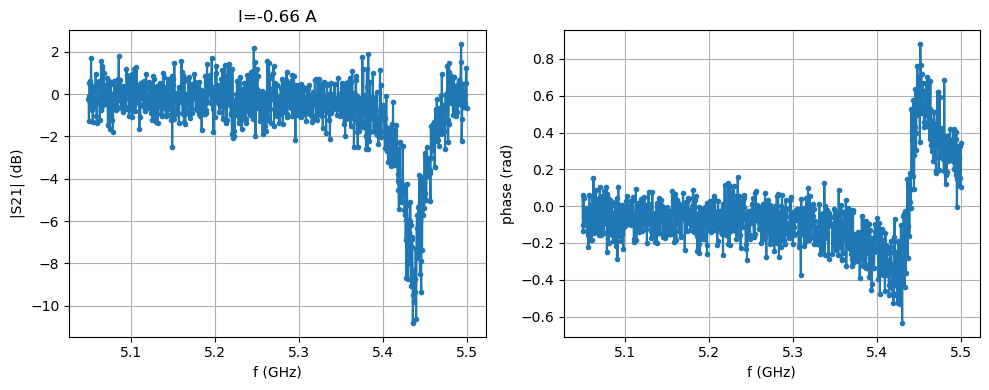

fitresults keys: ['Qi_dia_corr', 'Qi_no_corr', 'absQc', 'Qc_dia_corr', 'Ql', 'fr', 'theta0', 'phi0', 'phi0_err', 'Ql_err', 'absQc_err', 'fr_err', 'chi_square', 'Qi_no_corr_err', 'Qi_dia_corr_err']


In [48]:
# Pick one current and fit
some_I, idx = next(iter(groups.items()))
fitres, aux = fit_notch_trace(Freq[idx], Z[idx], electric_delay_guess=ELECTRIC_DELAY_GUESS)
print("One-trace fit:", fitres)

# Optional: visualize magnitude and phase to confirm the notch is there
f_sorted, z_sorted, port = aux
plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.plot(f_sorted/1e9, 20*np.log10(np.abs(z_sorted)), '.-'); plt.grid(True)
plt.xlabel('f (GHz)'); plt.ylabel('|S21| (dB)'); plt.title(f'I={some_I:.4g} A')
plt.subplot(1,2,2); plt.plot(f_sorted/1e9, np.unwrap(np.angle(z_sorted)), '.-'); plt.grid(True)
plt.xlabel('f (GHz)'); plt.ylabel('phase (rad)')
plt.tight_layout(); plt.show()

# See what the fitter produced (helps debugging API differences)
if hasattr(port, 'fitresults'):
    print("fitresults keys:", list(port.fitresults.keys()))


In [49]:
rows = []
for Ival, idx in groups.items():
    f_trace = Freq[idx]
    z_trace = Z[idx]
    good = np.isfinite(f_trace) & np.isfinite(z_trace.real) & np.isfinite(z_trace.imag)
    if np.count_nonzero(good) < MIN_POINTS_PER_TRACE:
        continue
    try:
        fitres, _ = fit_notch_trace(f_trace[good], z_trace[good], electric_delay_guess=ELECTRIC_DELAY_GUESS)
        rows.append({'I': float(Ival), **fitres})
    except Exception as e:
        warnings.warn(f"Fit failed for I={Ival:.6g}: {e}")

df = pd.DataFrame(rows).sort_values('I').reset_index(drop=True)
print(f"Fitted {len(df)} traces (expected 216).")
df.head()

Fitted 216 traces (expected 216).


,I,f0,Ql,Qi,Qc,phi,delay,npoints
0,-0.66,5.444620e+09,117.217075,324.378684,183.541346,-0.314525,NaN,901
1,-0.65,5.445308e+09,115.132859,324.212874,178.532392,-0.336342,NaN,901
2,-0.64,5.444605e+09,116.526174,320.406423,183.125804,-0.326070,NaN,901
3,-0.63,5.444654e+09,111.705755,312.003189,174.003986,-0.326115,NaN,901
4,-0.62,5.444125e+09,118.035856,341.617701,180.350680,-0.306832,NaN,901


In [50]:
import numpy as np
import matplotlib.pyplot as plt

import numpy as np
import matplotlib.pyplot as plt

def plot_fit_for_current(I_value, Freq, Z, groups, electric_delay_guess=None):
    """
    Re-fit the trace for current I_value and plot:
    - |S21| (dB) vs f with fit overlay
    - phase vs f with fit overlay
    - I-Q circle (data and fit)
    Accepts an exact key from groups or a float close to an existing key.
    """
    # Resolve the key robustly
    if I_value in groups:
        key = I_value
    else:
        keys = np.array(list(groups.keys()))
        key = keys[np.argmin(np.abs(keys - I_value))]

    idx = groups[key]
    f_trace = Freq[idx]
    z_trace = Z[idx]
    good = np.isfinite(f_trace) & np.isfinite(z_trace.real) & np.isfinite(z_trace.imag)
    f_trace = f_trace[good]
    z_trace = z_trace[good]

    # Fit (re-use your fit_notch_trace)
    fitres, (f_sorted, z_sorted, port) = fit_notch_trace(f_trace, z_trace, electric_delay_guess=electric_delay_guess)

    # Try to get the fitted curve from the port object
    f_fit = getattr(port, 'f_data', f_sorted)
    z_fit = getattr(port, 'z_data_fit', None)
    if z_fit is None:
        for name in ['z_fit', 'z_model', 'z_theory', 'z_data_sim', 'z_sim']:
            if hasattr(port, name):
                z_fit = getattr(port, name)
                break

    # Make plots
    fig, axs = plt.subplots(1, 3, figsize=(14, 4.2))

    # |S21| (dB)
    axs[0].plot(f_sorted/1e9, 20*np.log10(np.abs(z_sorted)), 'b.', ms=3, label='data')
    if z_fit is not None:
        axs[0].plot(f_fit/1e9, 20*np.log10(np.abs(z_fit)), 'r-', lw=1.5, label='fit')
    axs[0].set_xlabel('f (GHz)'); axs[0].set_ylabel('|S21| (dB)'); axs[0].grid(True)
    axs[0].legend(loc='best')

    # phase (rad)
    axs[1].plot(f_sorted/1e9, np.unwrap(np.angle(z_sorted)), 'b.', ms=3, label='data')
    if z_fit is not None:
        axs[1].plot(f_fit/1e9, np.unwrap(np.angle(z_fit)), 'r-', lw=1.5, label='fit')
    axs[1].set_xlabel('f (GHz)'); axs[1].set_ylabel('phase (rad)'); axs[1].grid(True)

    # I-Q circle
    axs[2].plot(np.real(z_sorted), np.imag(z_sorted), 'b.', ms=3, label='data')
    if z_fit is not None:
        axs[2].plot(np.real(z_fit), np.imag(z_fit), 'r-', lw=1.5, label='fit')
    axs[2].set_xlabel('Re(S21)'); axs[2].set_ylabel('Im(S21)')
    axs[2].set_aspect('equal', adjustable='box'); axs[2].grid(True)

    fr = fitres.get('f0', None)
    Ql = fitres.get('Ql', None)
    Qi = fitres.get('Qi', None)
    Qc = fitres.get('Qc', None)
    phi = fitres.get('phi', None)
    title = f"I={float(key):.6g} A"
    if fr is not None:  title += f" | f0={fr/1e9:.4f} GHz"
    if Ql is not None:  title += f" | Ql={Ql:.2g}"
    if Qi is not None:  title += f" | Qi={Qi:.2g}"
    if Qc is not None:  title += f" | Qc={Qc:.2g}"
    if phi is not None and np.isfinite(phi): title += f" | phi={phi:.3f}"
    fig.suptitle(title, fontsize=11)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


def plot_n_examples_by_regions(n_per_region=9, electric_delay_guess=None):
    """
    Plot n_per_region currents from each of three regions in the sorted
    unique current list:
      - Region 1: indices 1..101   (0..100 in 0-based)
      - Region 2: indices 102..120 (101..119 in 0-based)
      - Region 3: indices 121..216 (120..215 in 0-based)
    Each selected current will generate one figure with 3 panels.
    """
    I_vals_sorted = np.array(sorted(groups.keys()))
    total = len(I_vals_sorted)
    # Convert the 1-based ranges to 0-based Python index ranges (inclusive)
    regions = [
        (0,   min(100, total-1)),   # 1..101
        (101, min(119, total-1)),   # 102..120
        (120, min(215, total-1)),   # 121..216
    ]

    for ridx, (i0, i1) in enumerate(regions, start=1):
        if i1 < i0:
            print(f"Region {ridx} is empty, skipping.")
            continue
        picks = np.linspace(i0, i1, num=min(n_per_region, i1 - i0 + 1), dtype=int)
        print(f"Region {ridx}: picking {len(picks)} currents from indices {i0+1}..{i1+1} of {total}")
        for p in picks:
            key = I_vals_sorted[p]   # exact dict key
            plot_fit_for_current(key, Freq, Z, groups, electric_delay_guess=electric_delay_guess)



Region 1: picking 19 currents from indices 1..101 of 216


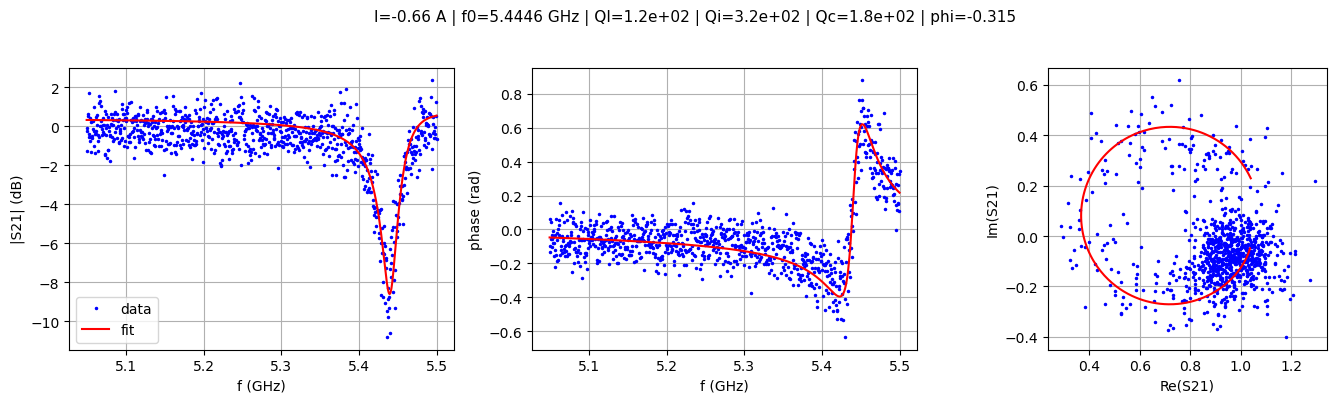

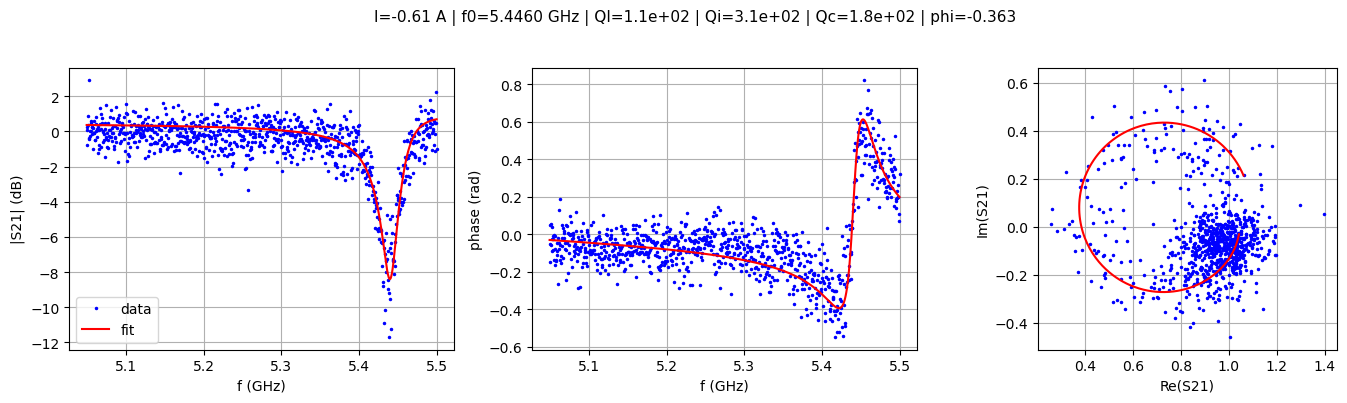

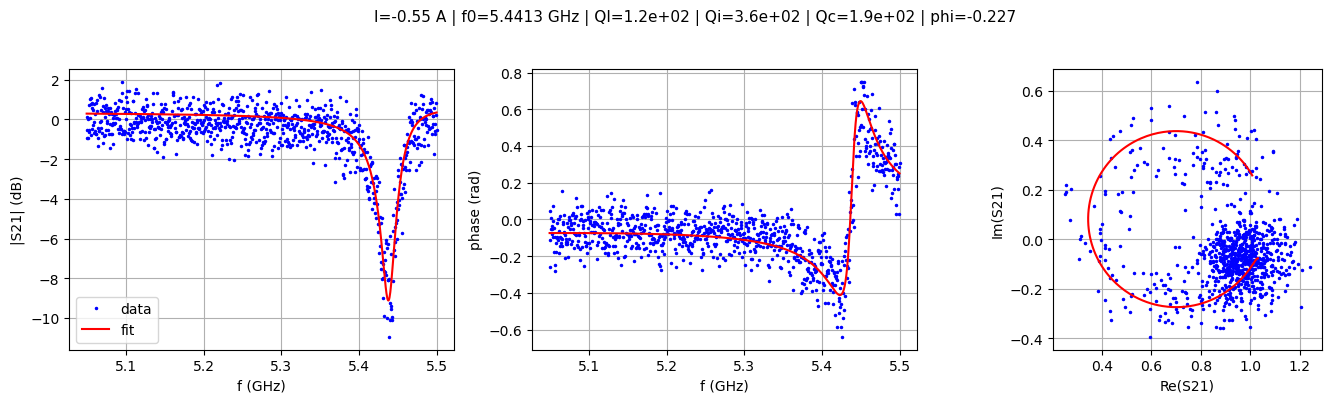

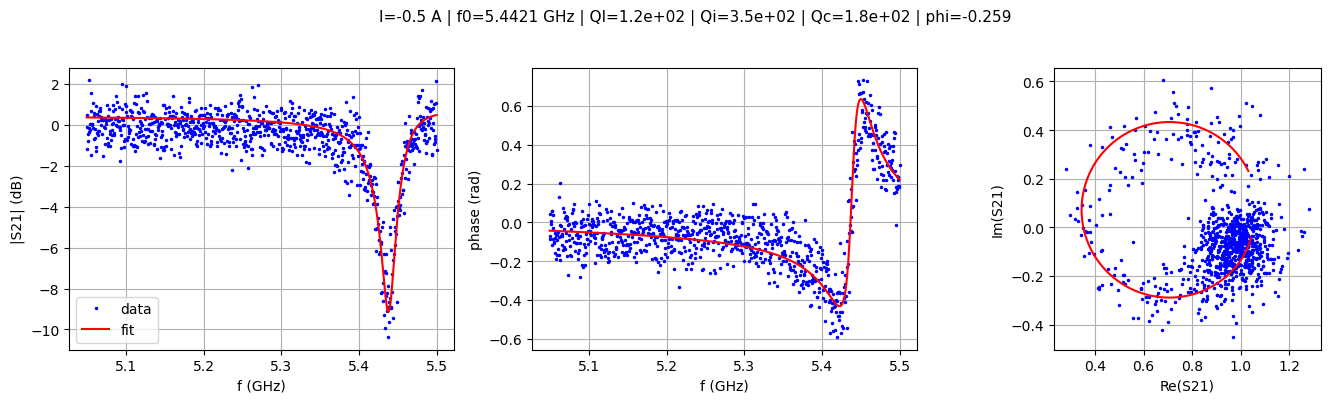

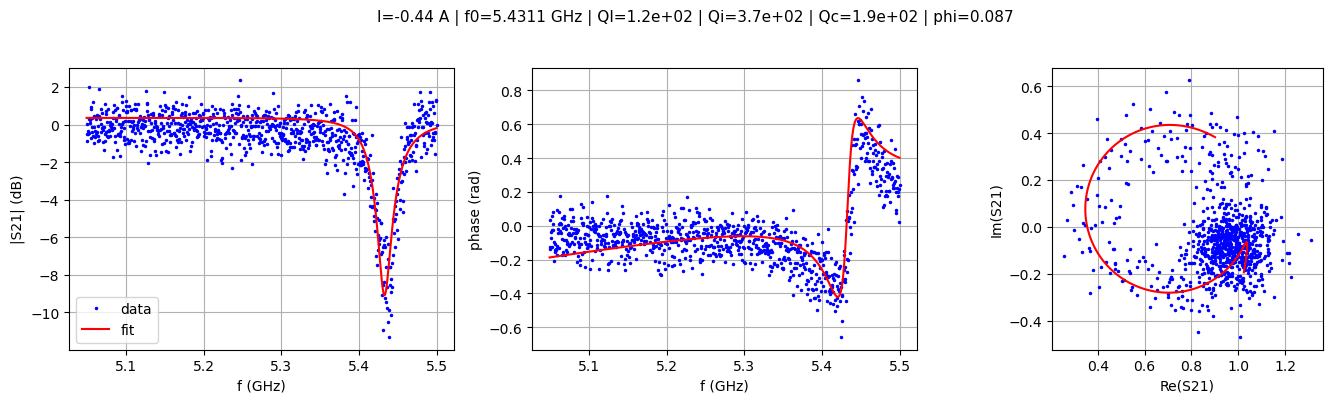

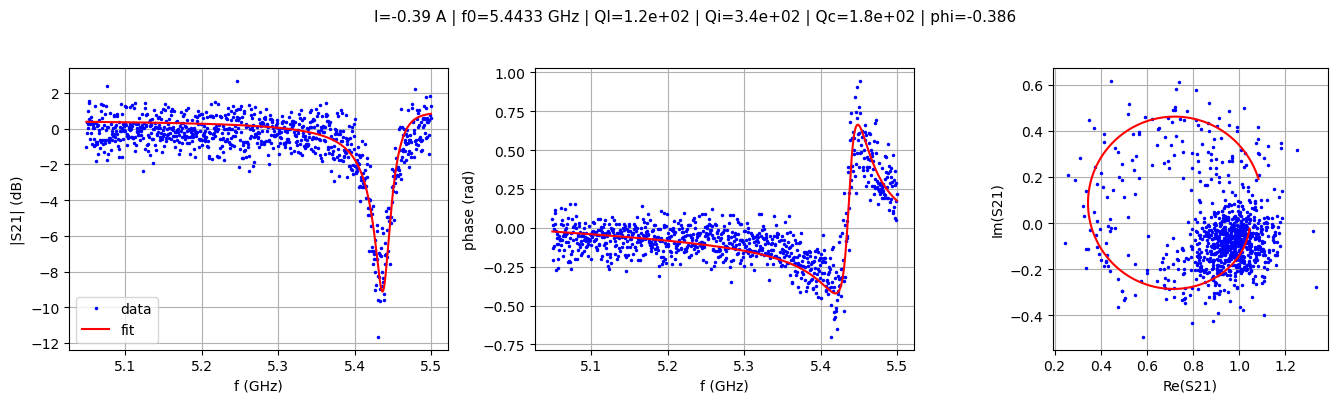

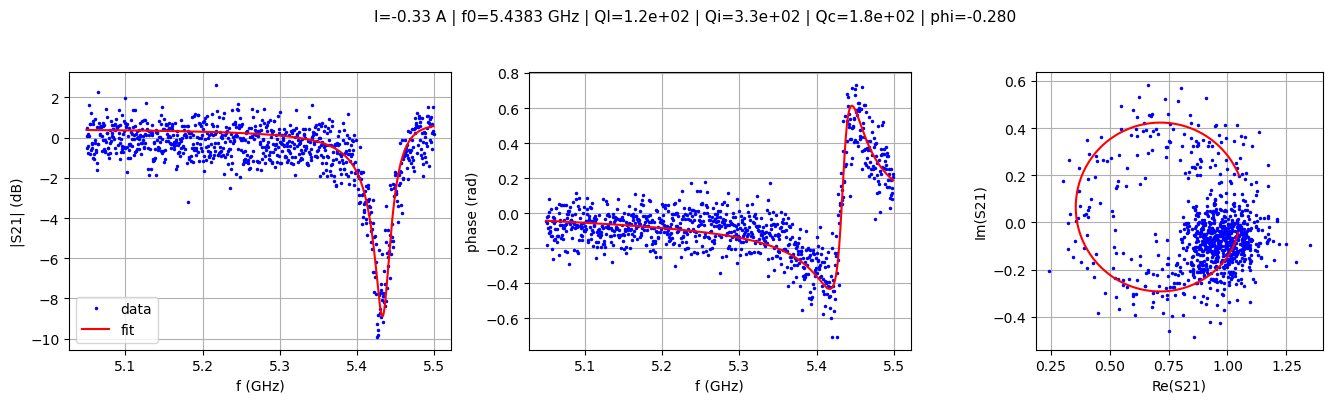

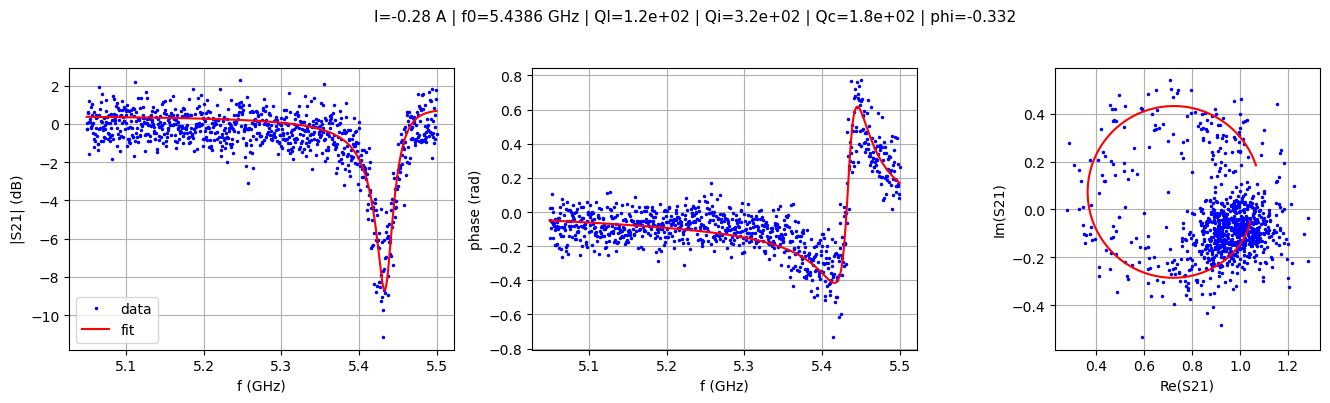

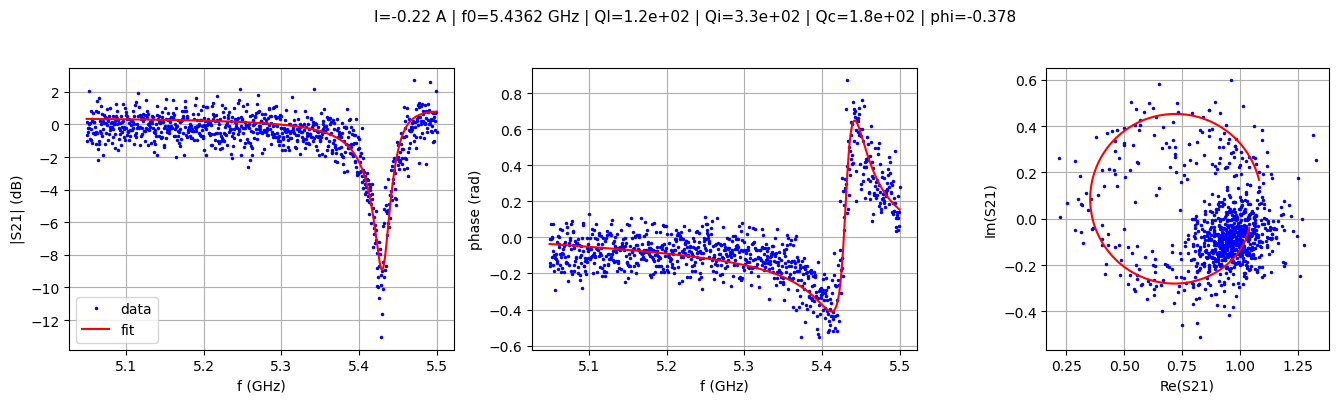

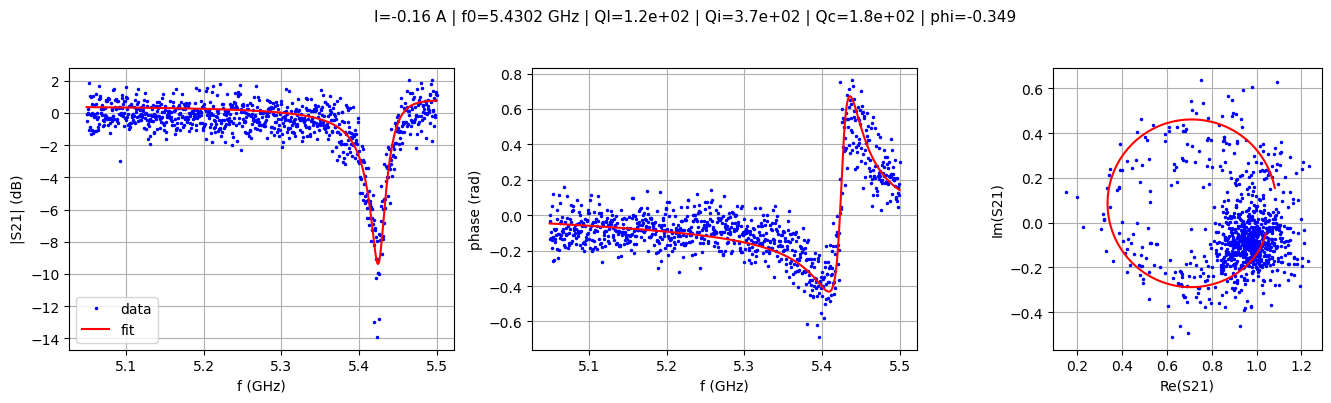

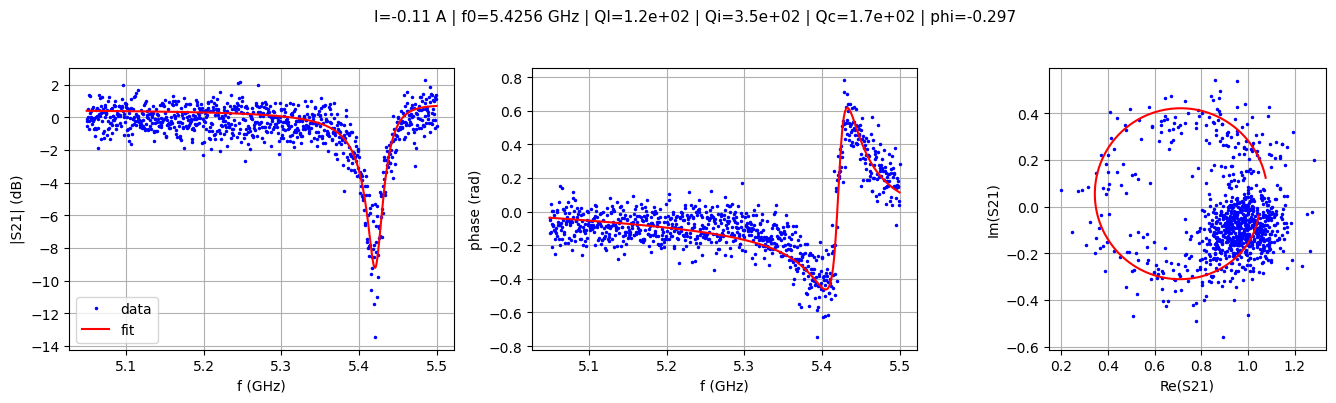

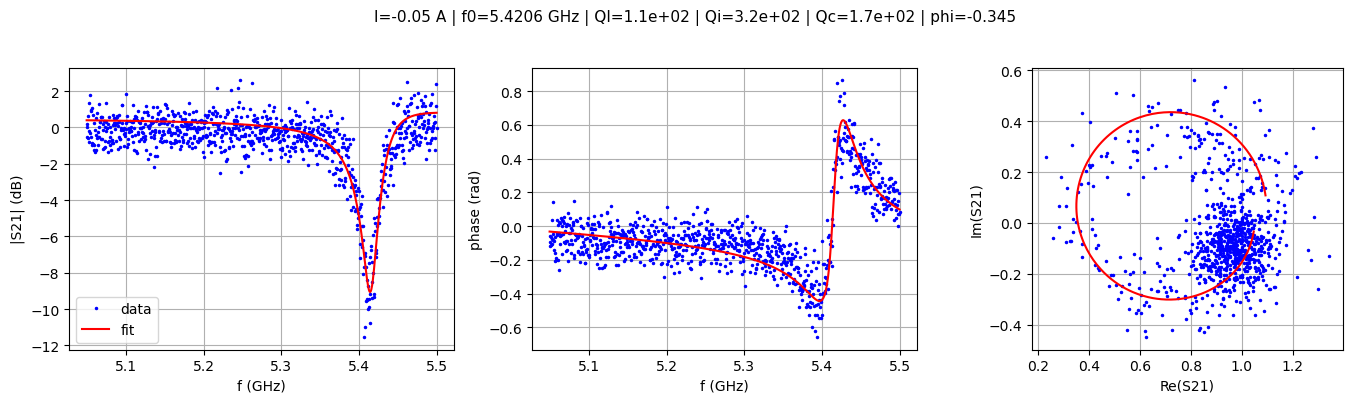

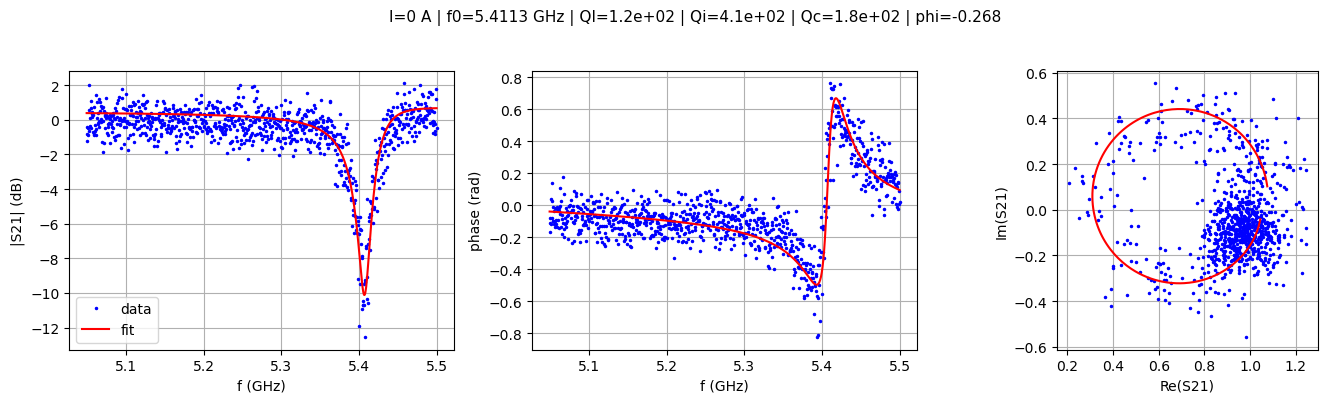

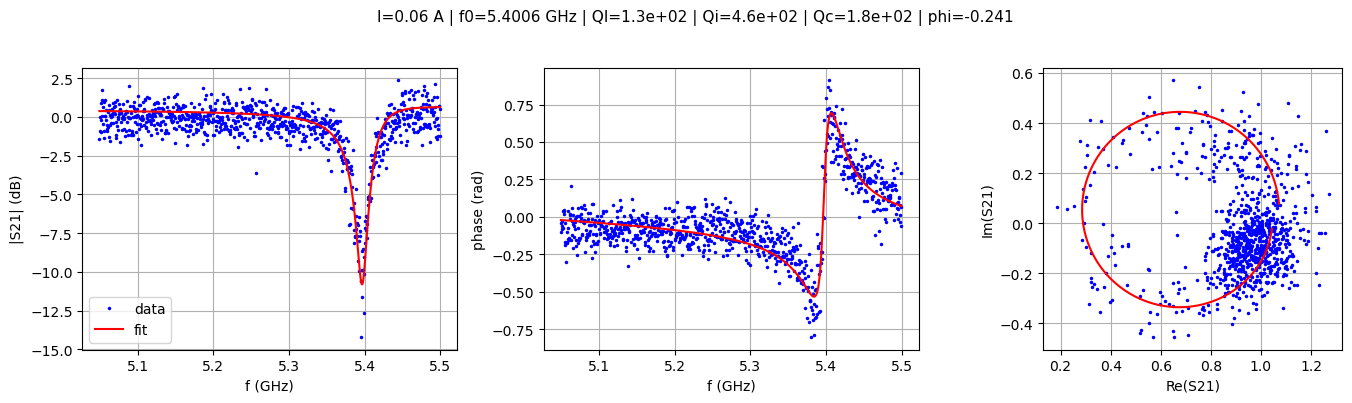

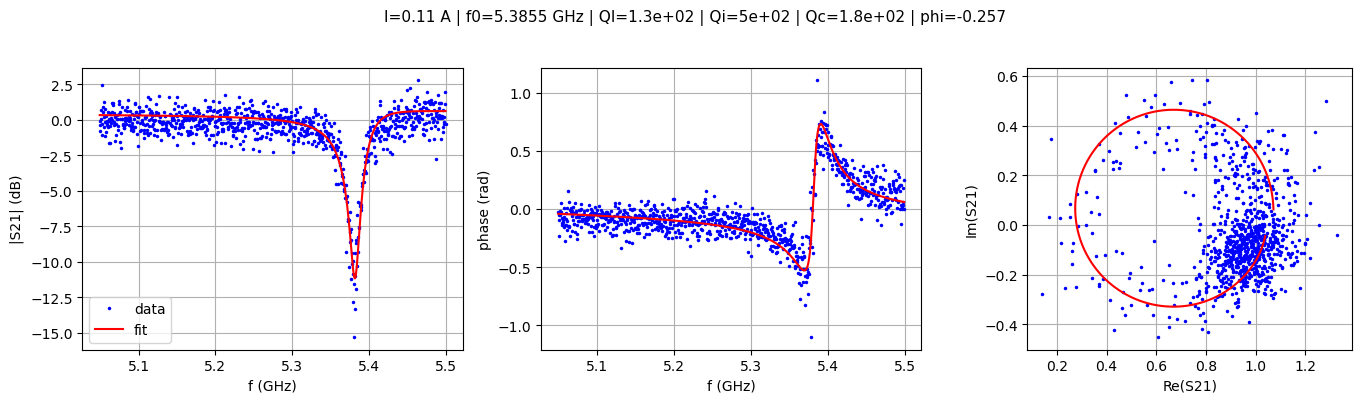

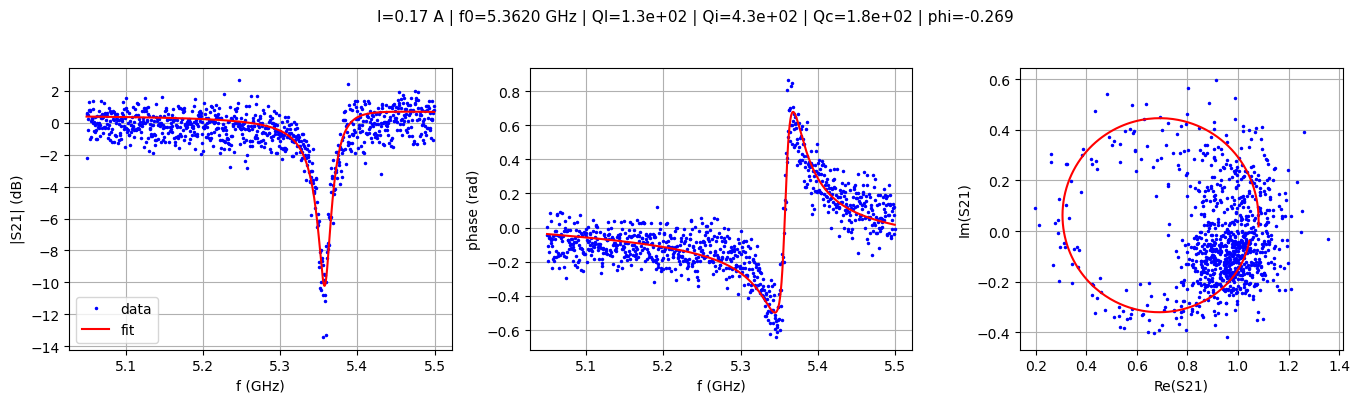

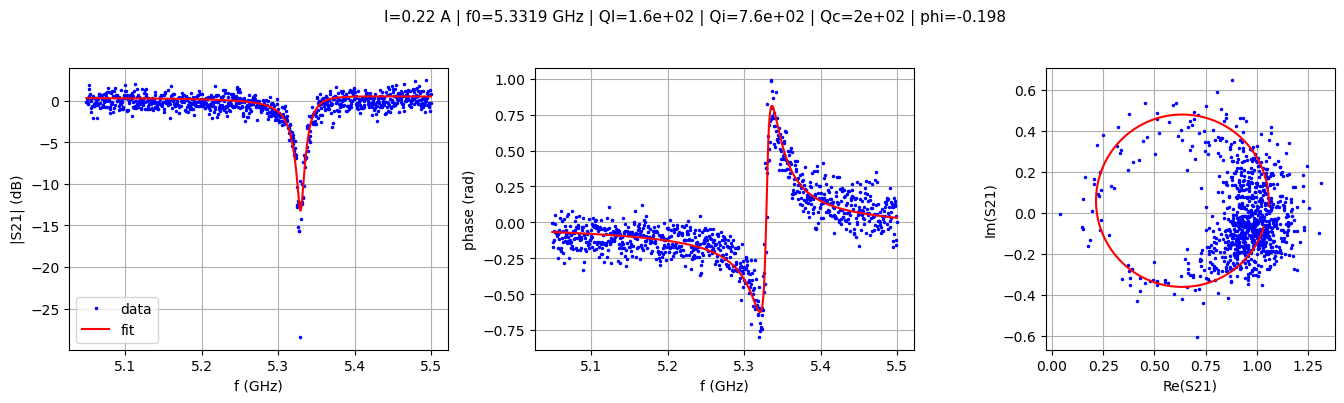

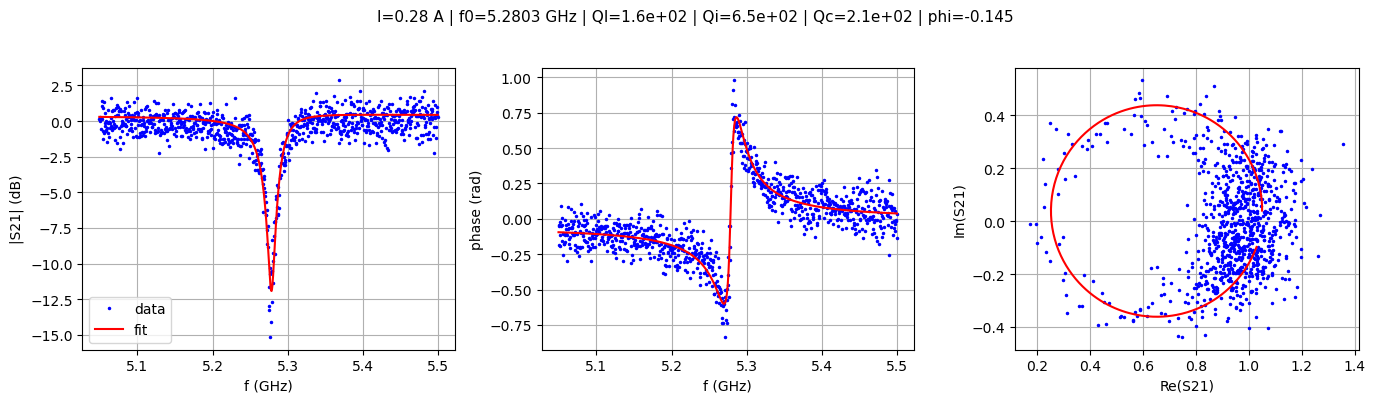

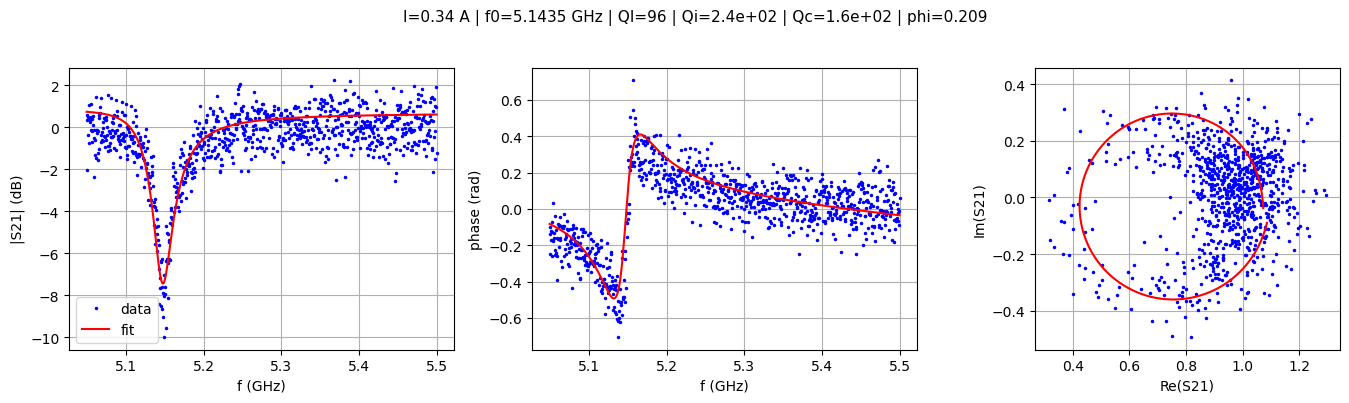

Region 2: picking 19 currents from indices 102..120 of 216


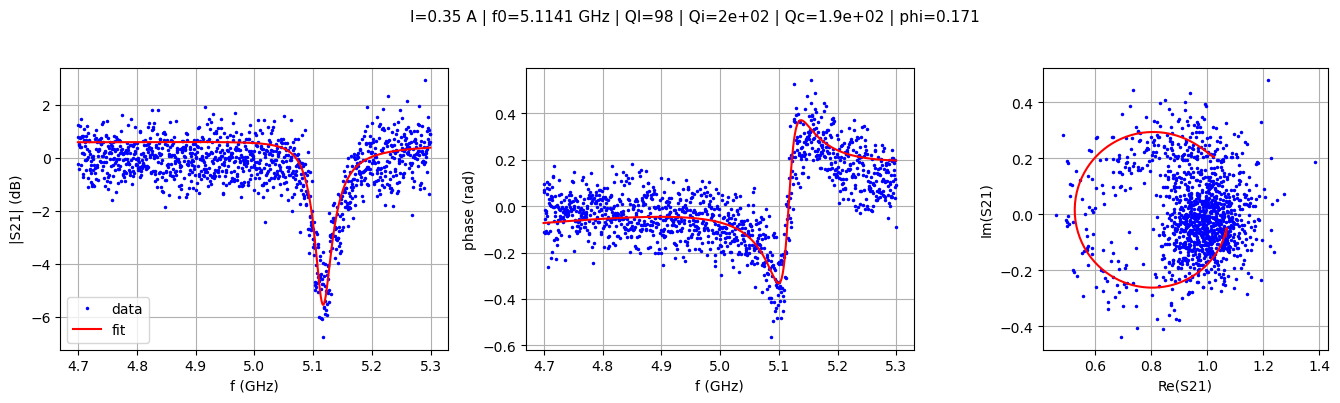

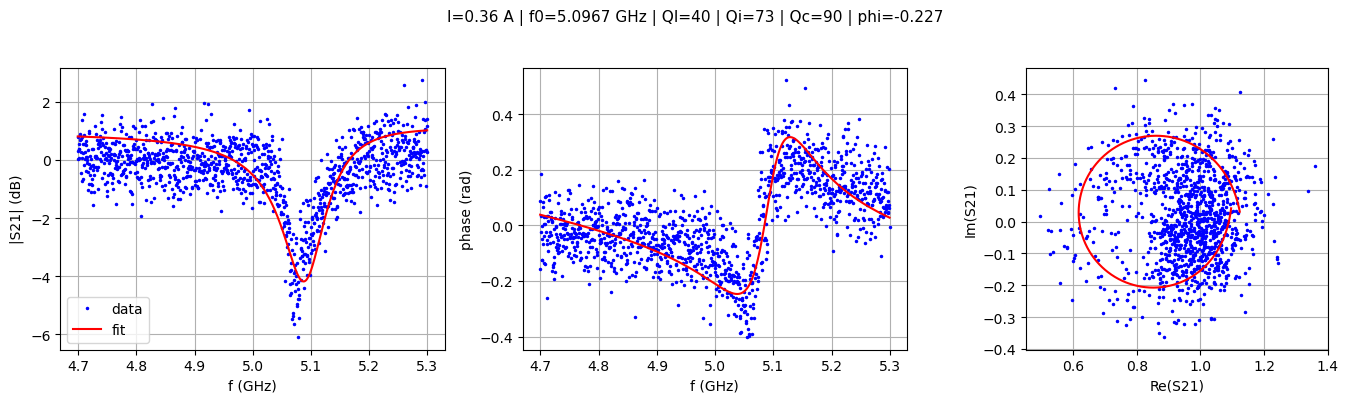

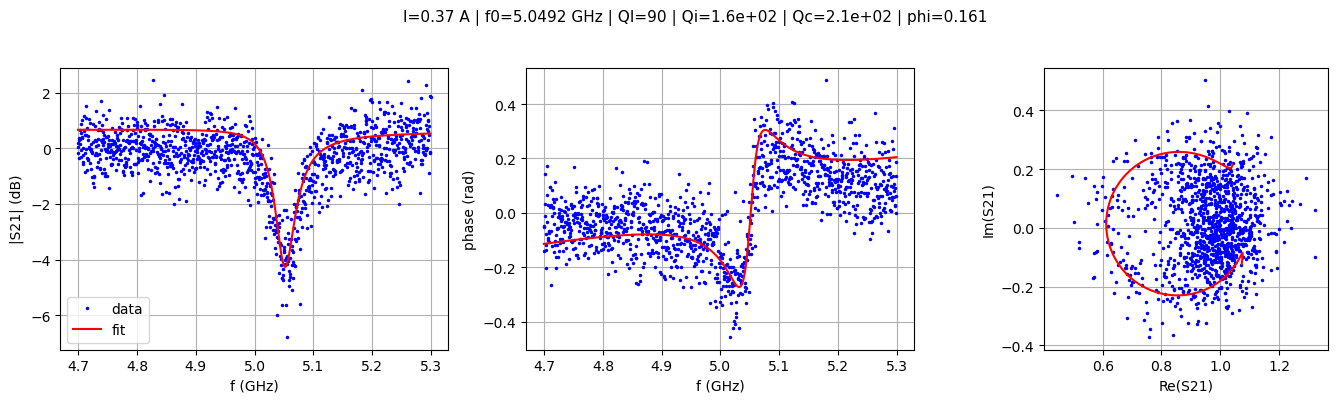

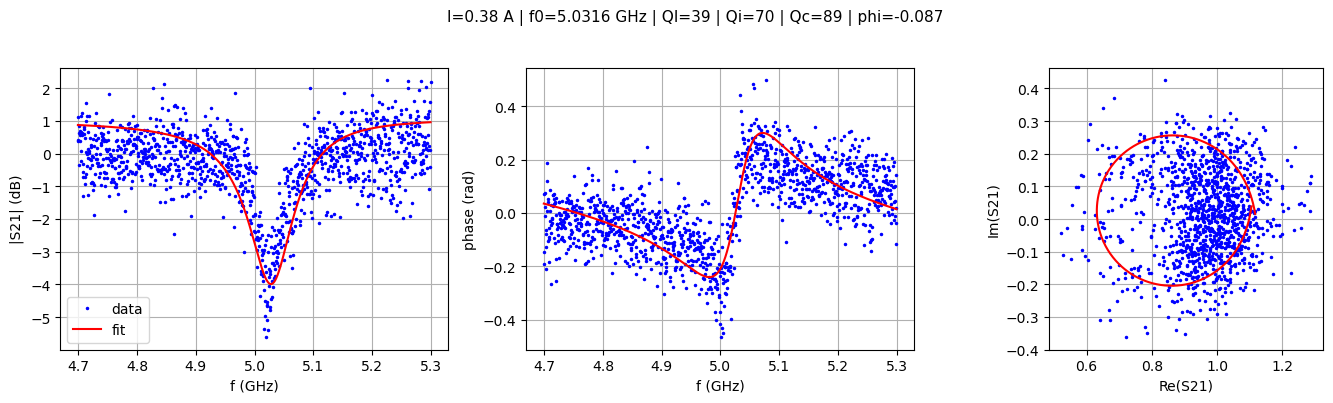

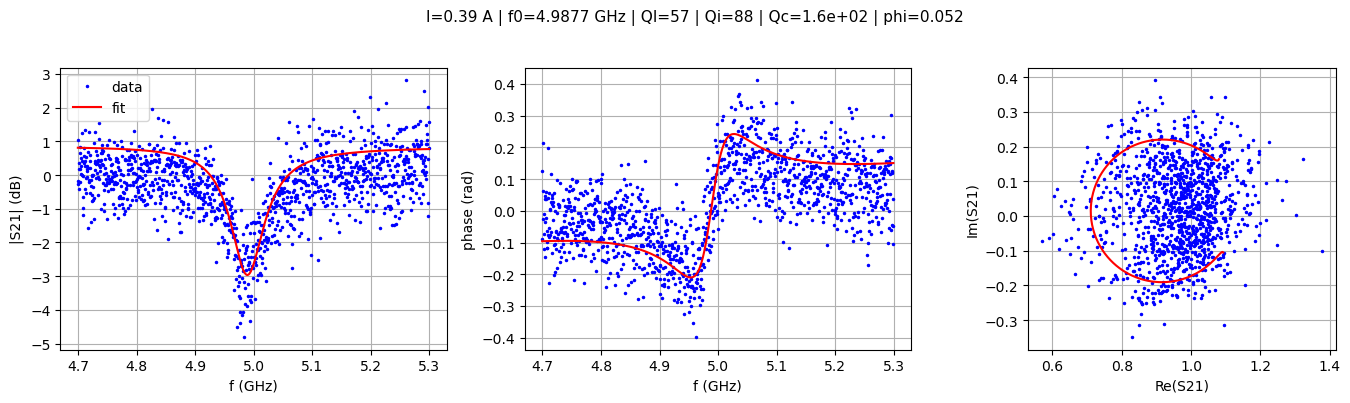

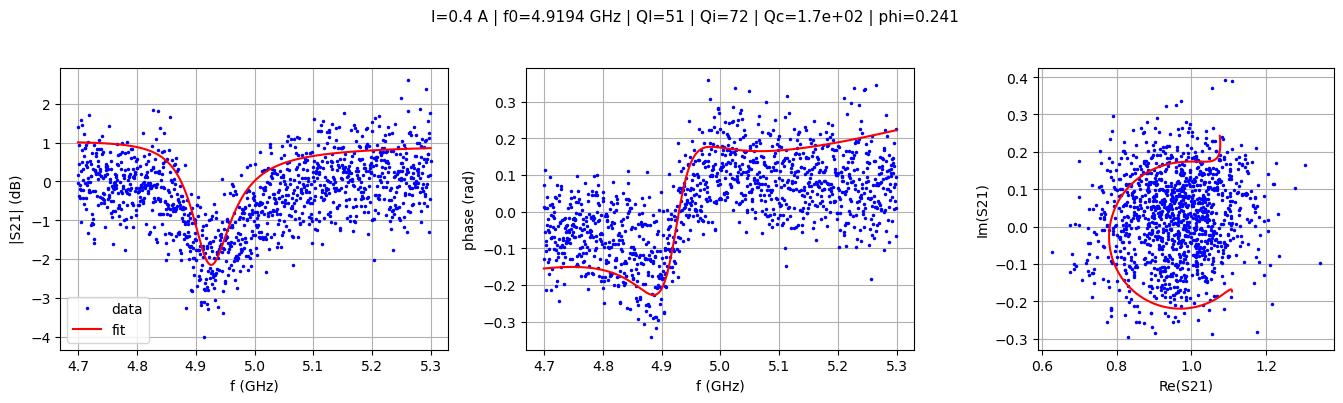

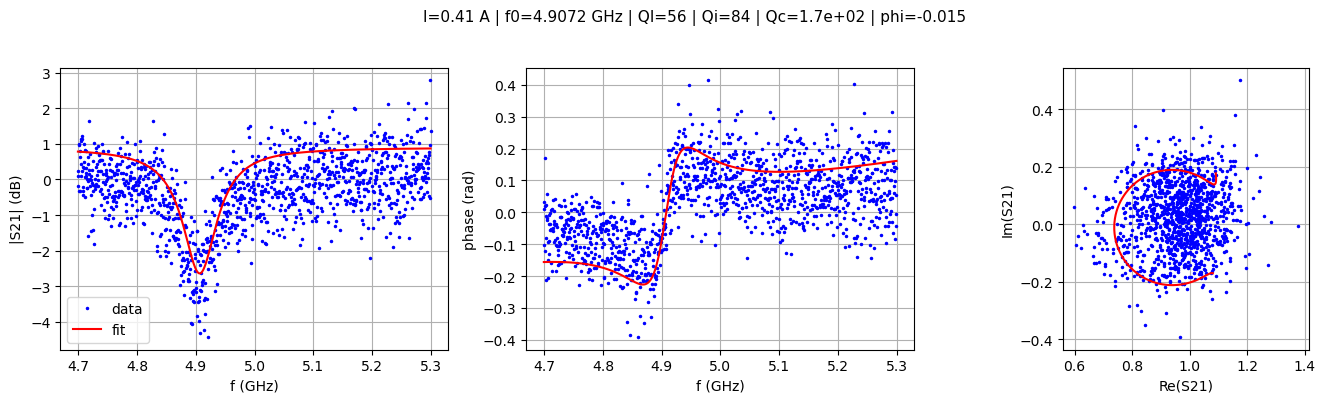

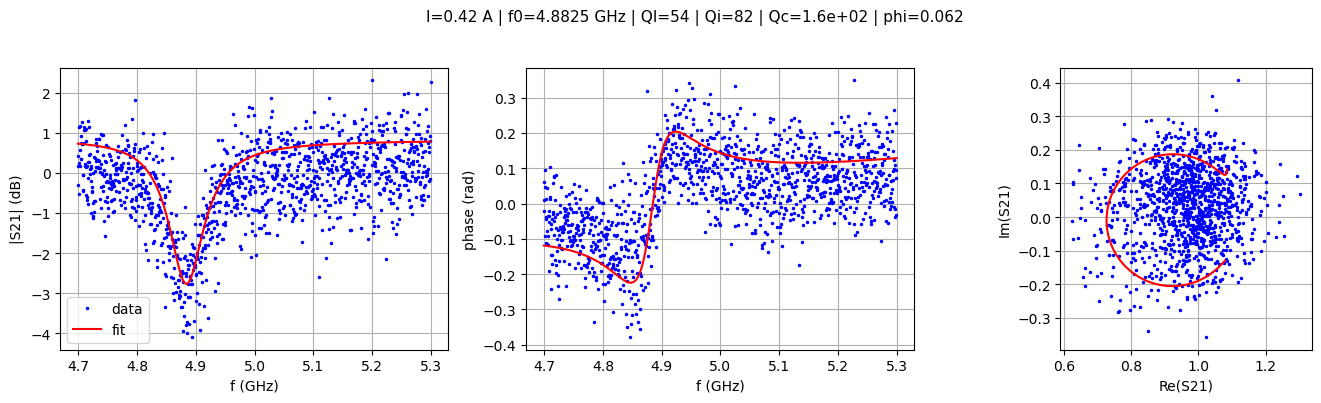

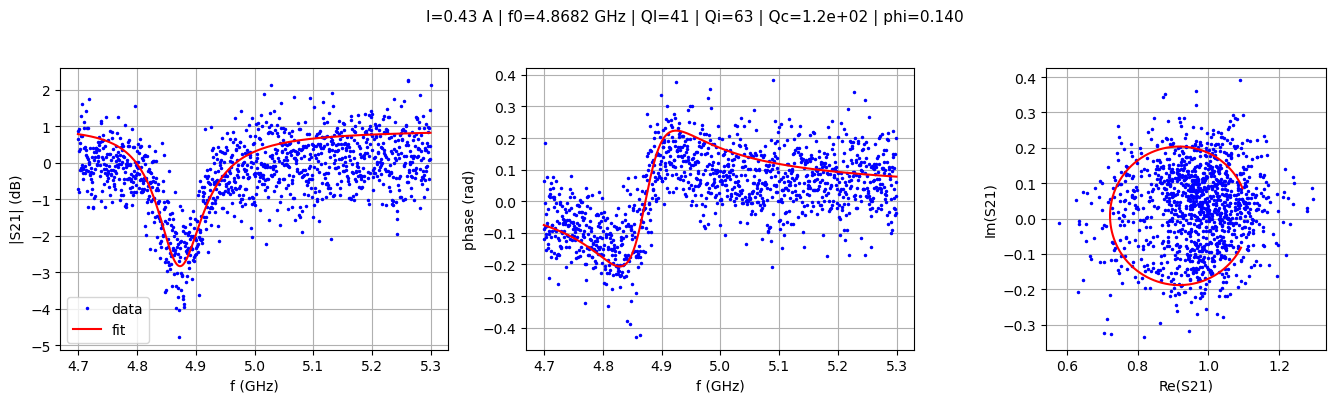

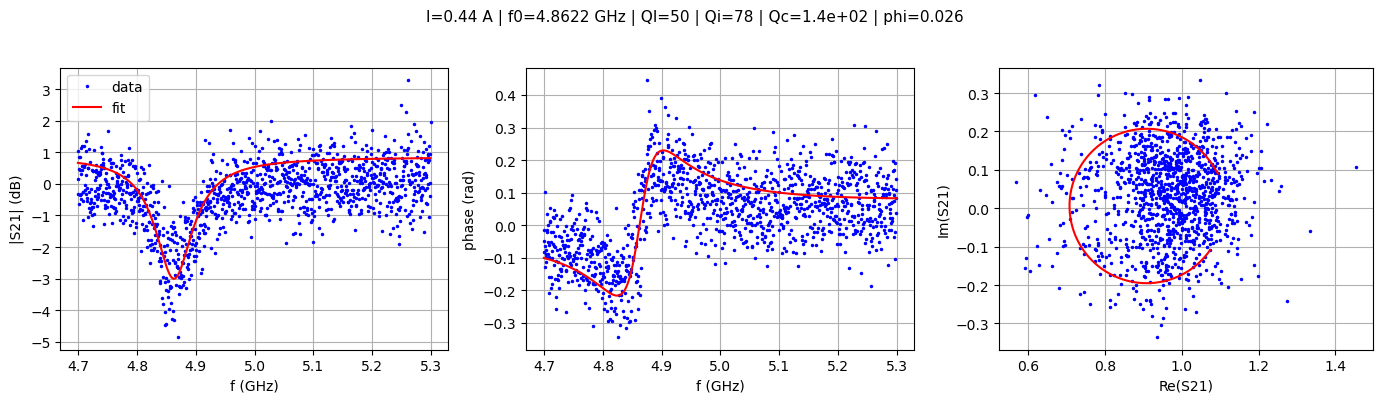

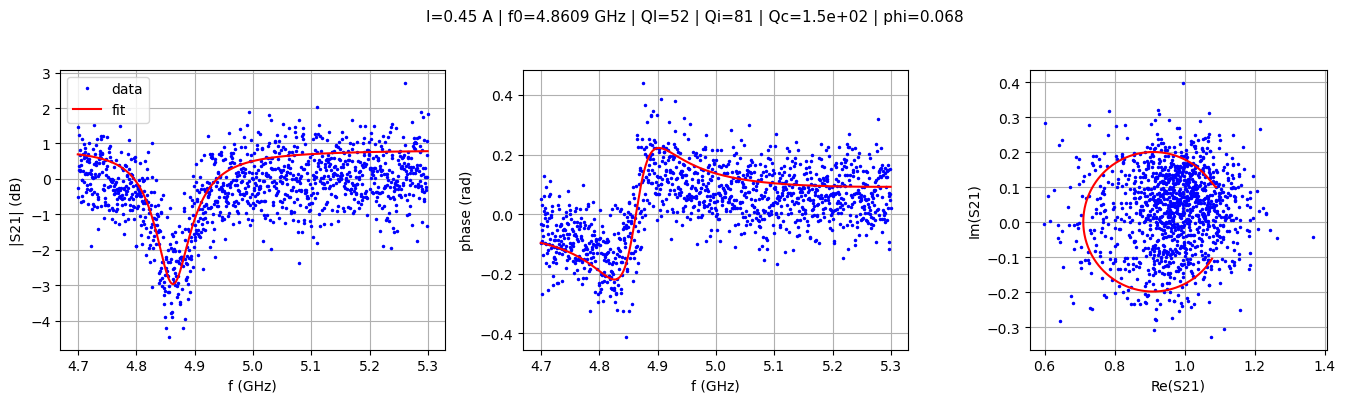

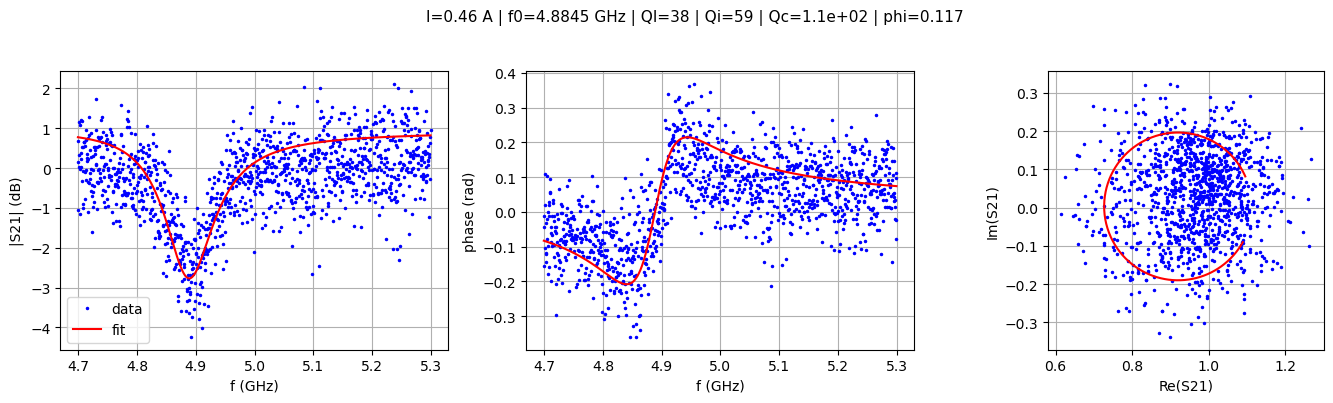

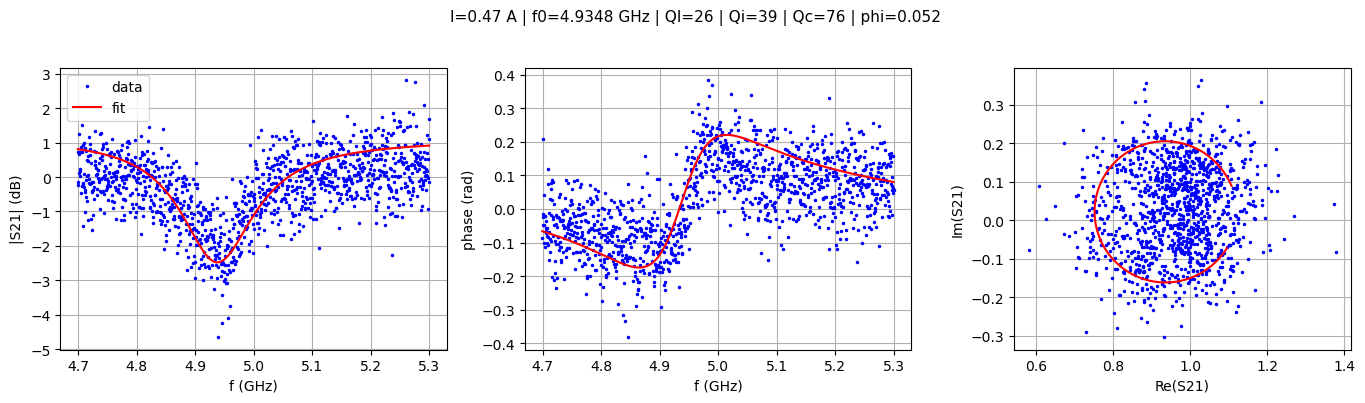

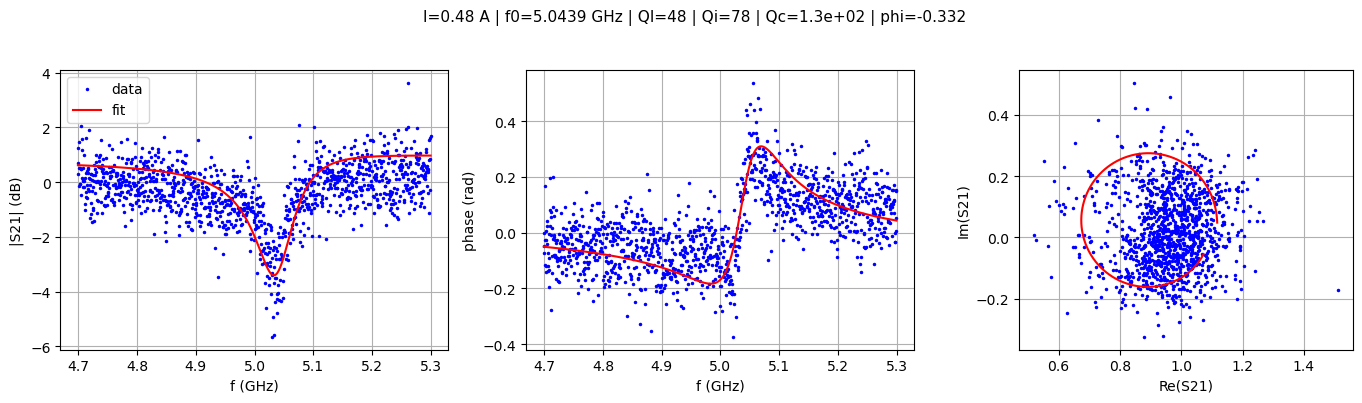

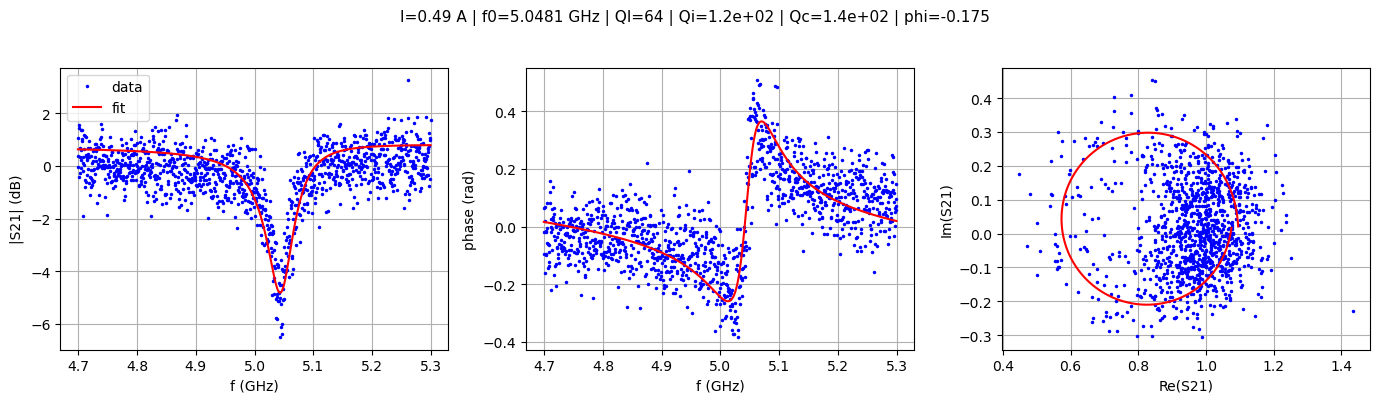

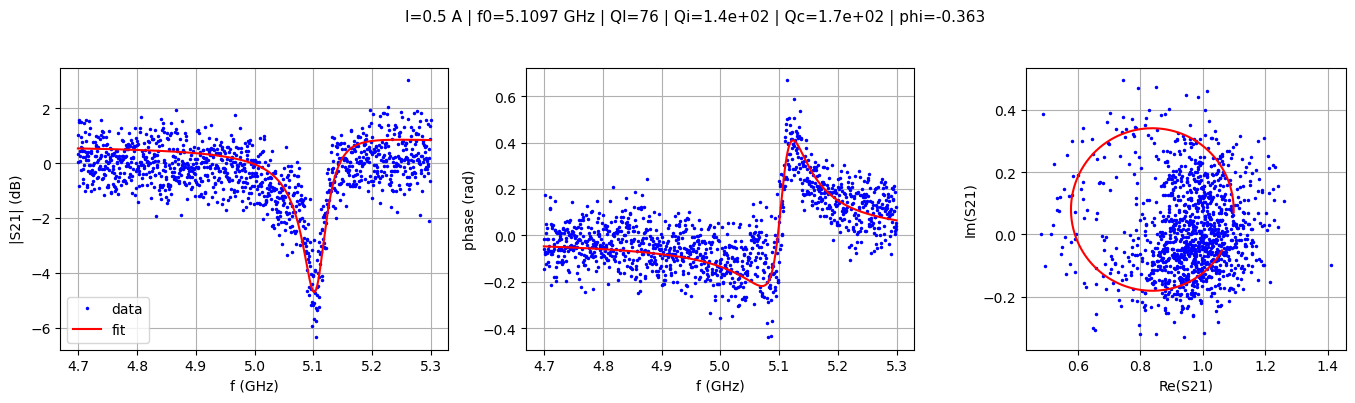

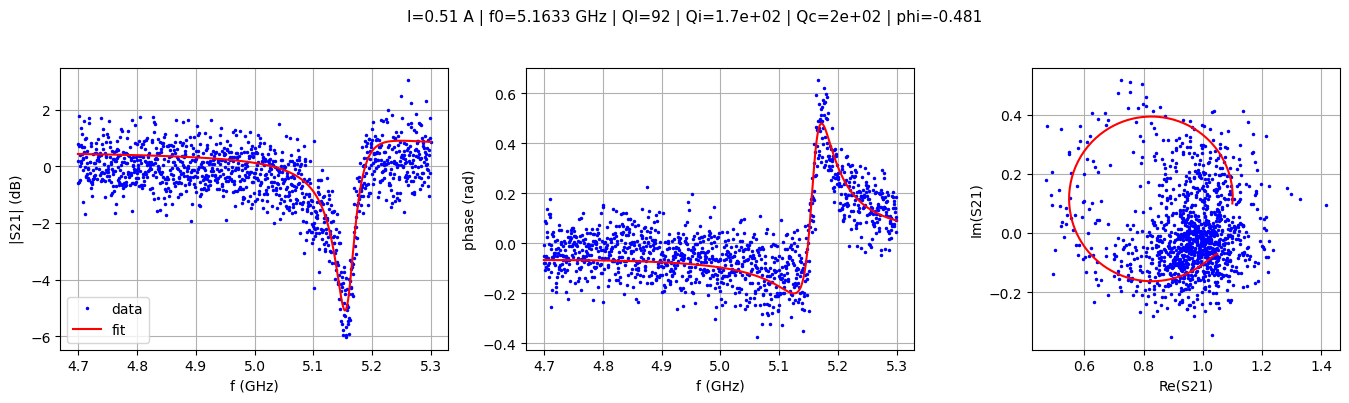

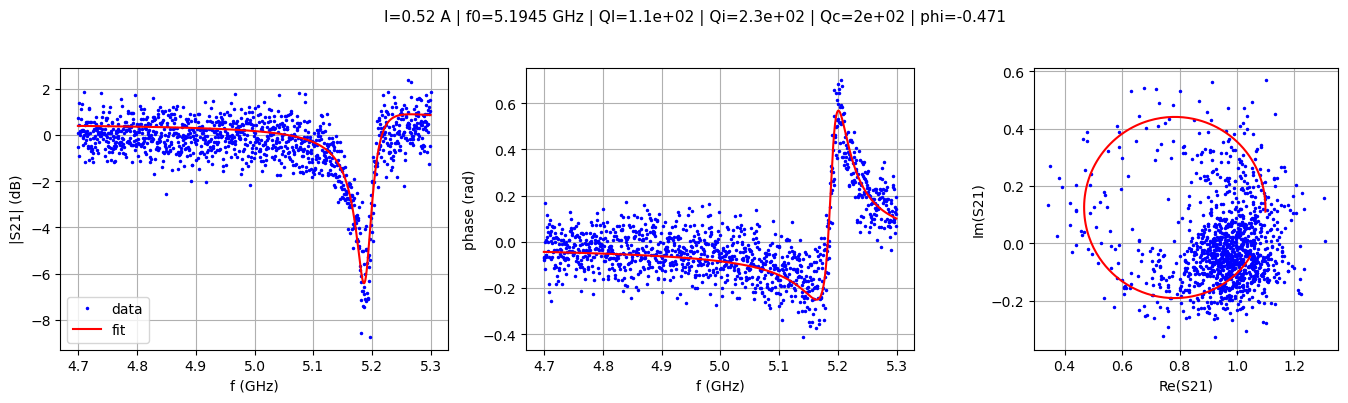

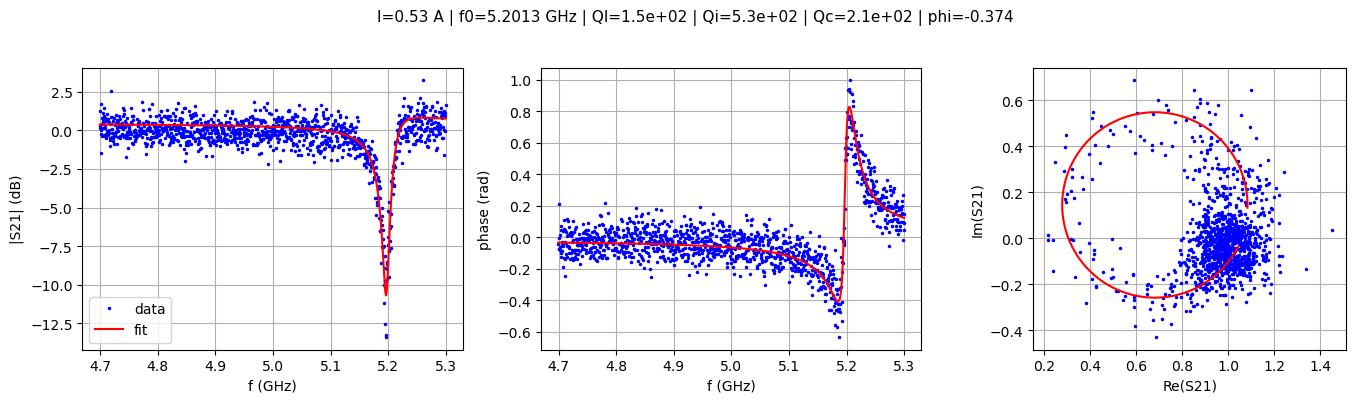

Region 3: picking 19 currents from indices 121..216 of 216


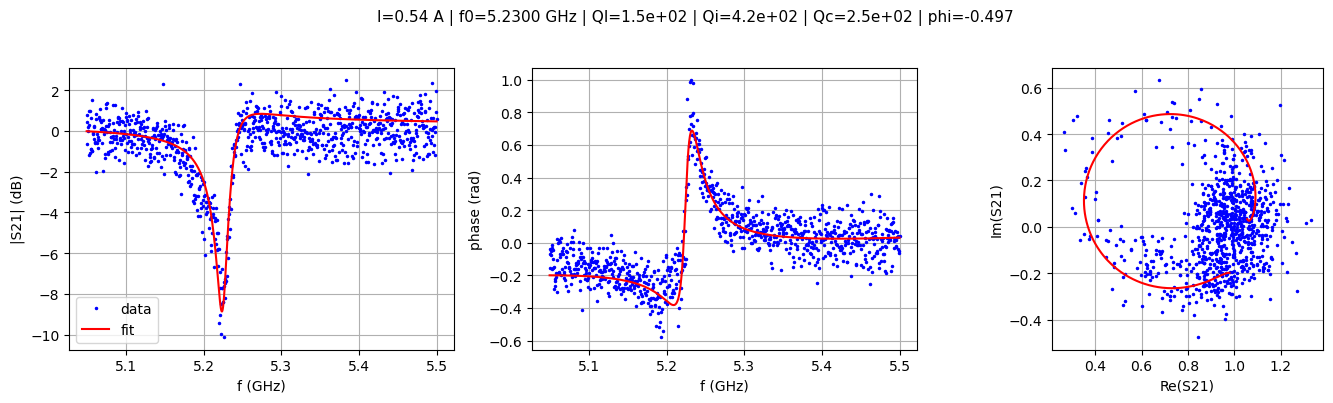

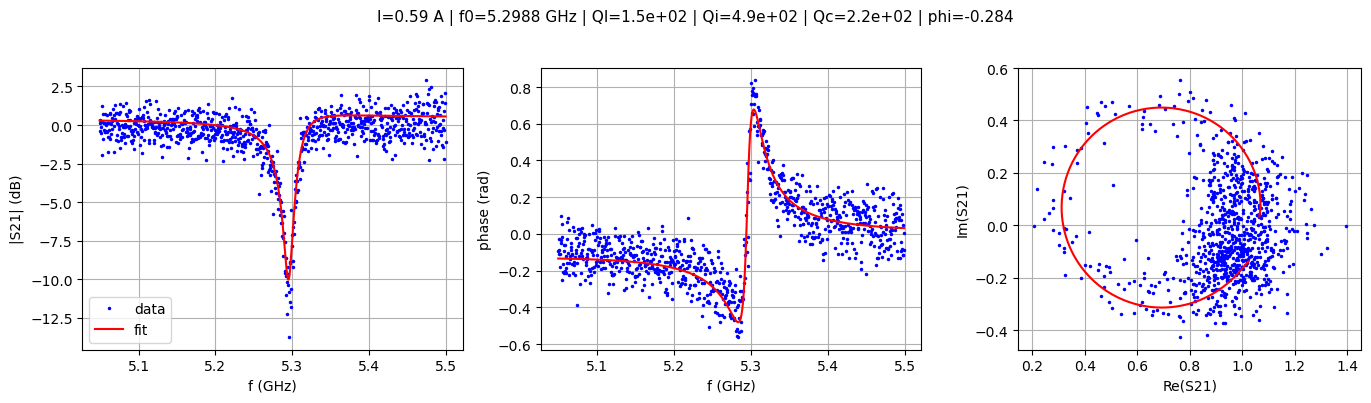

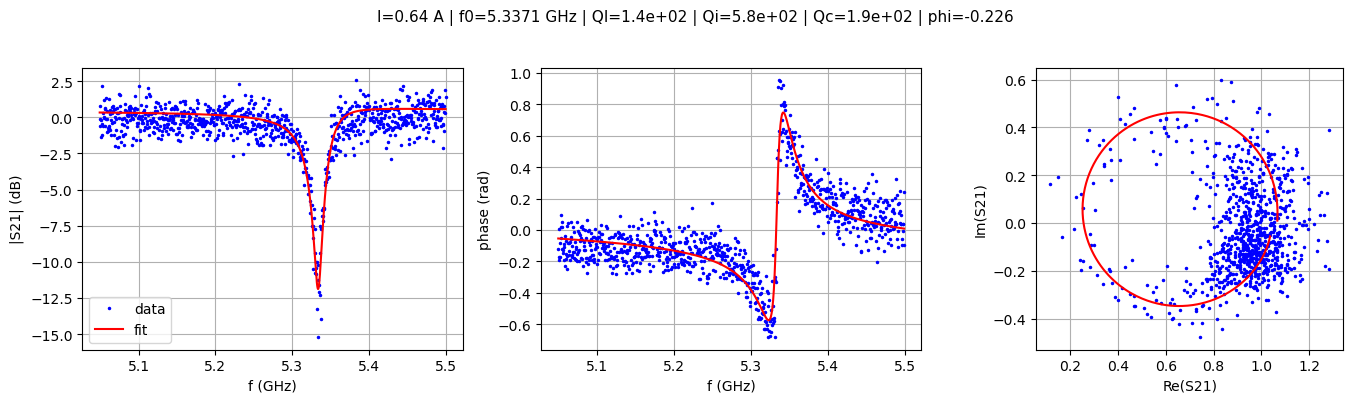

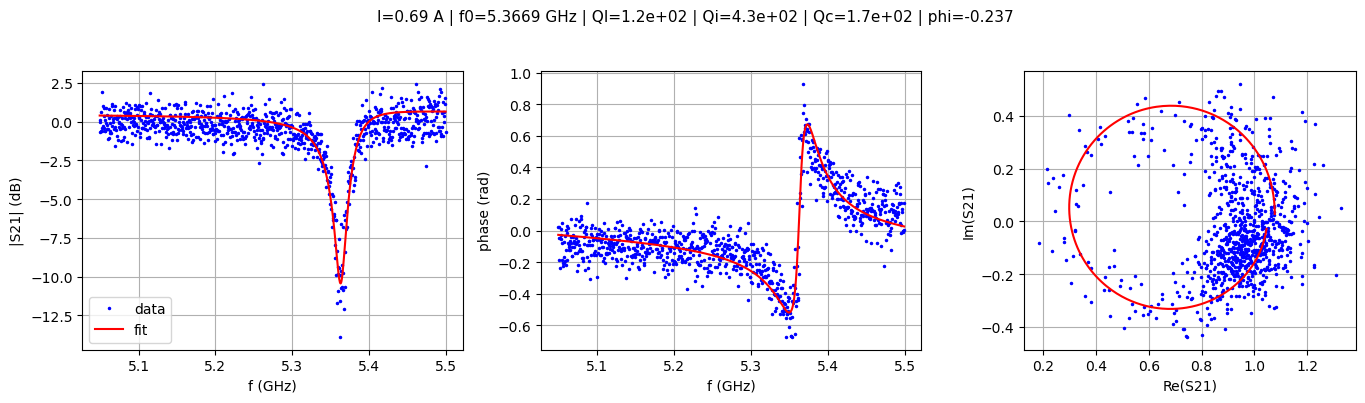

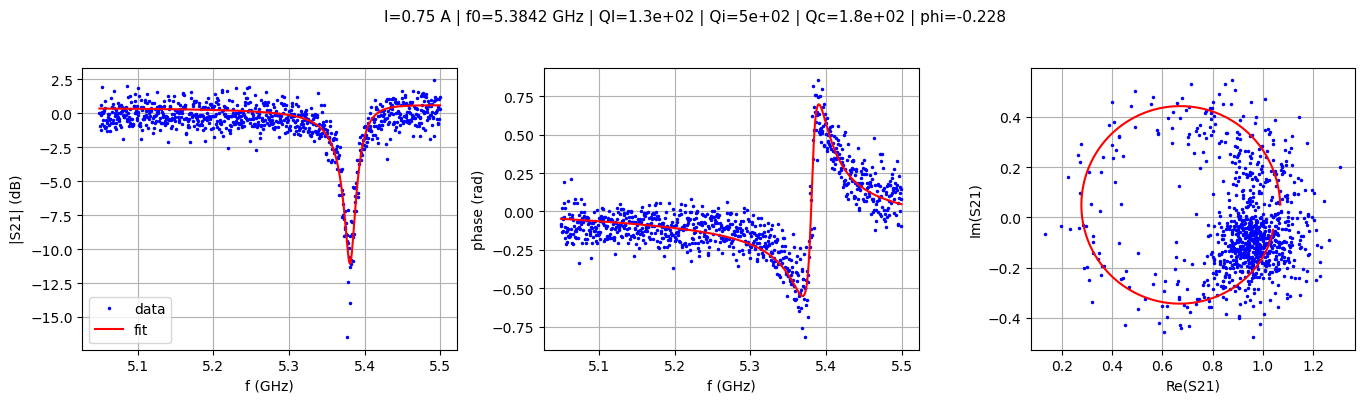

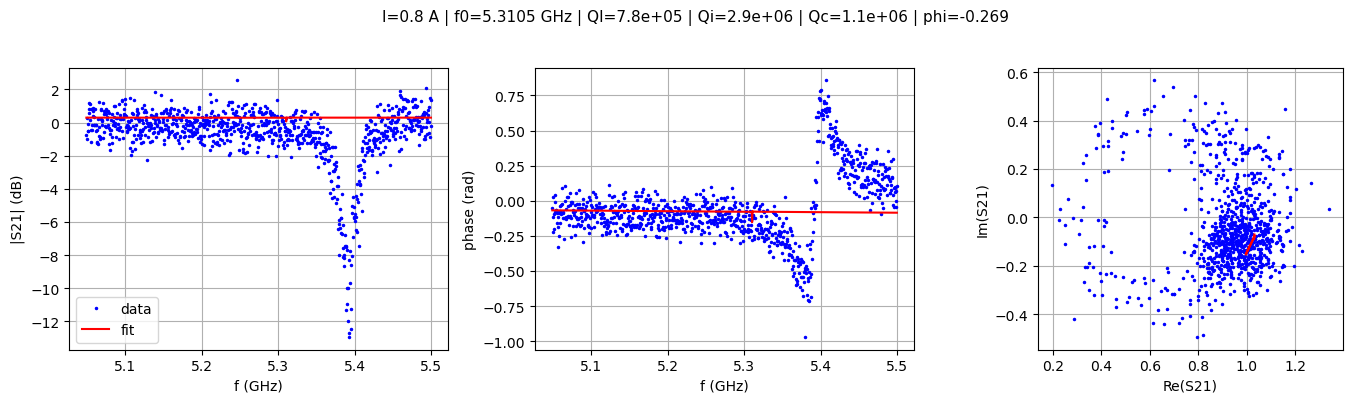

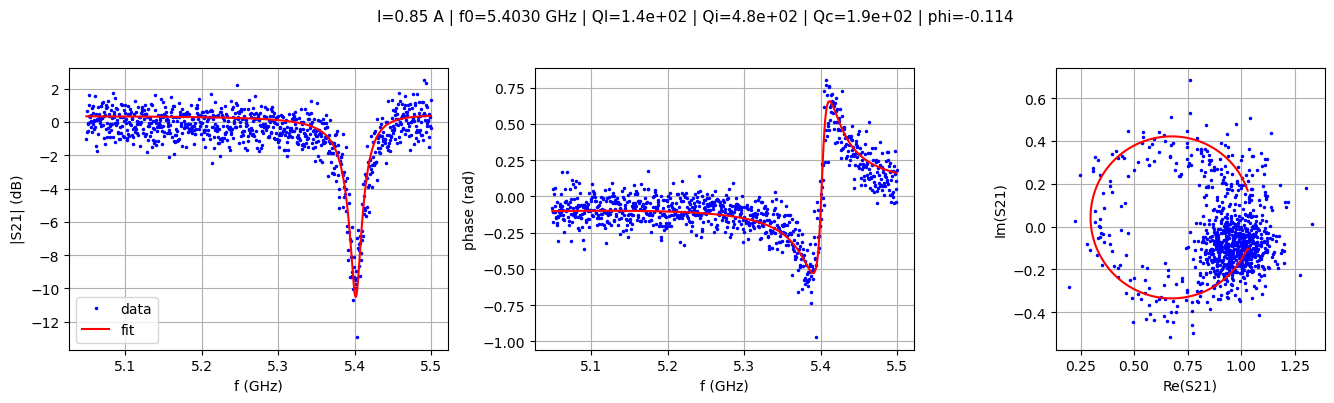

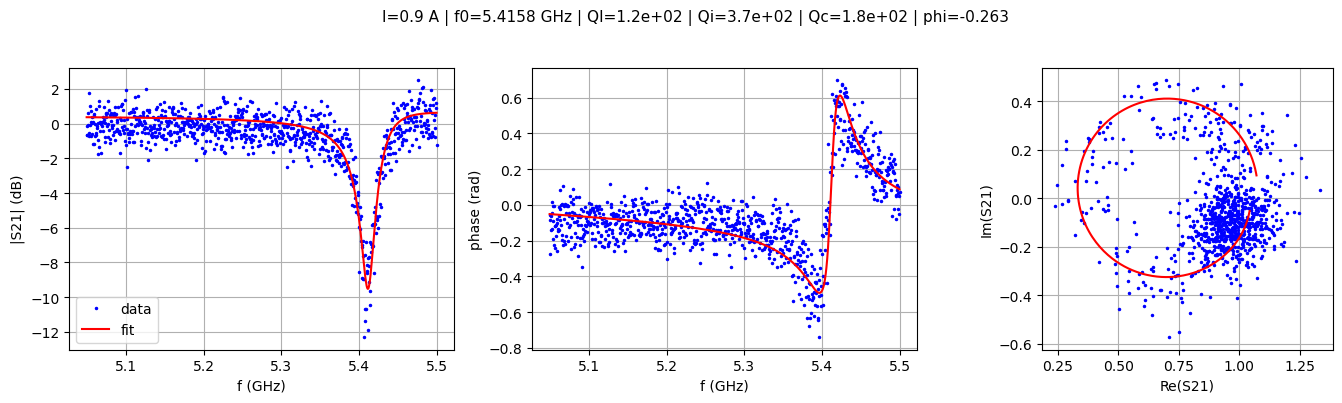

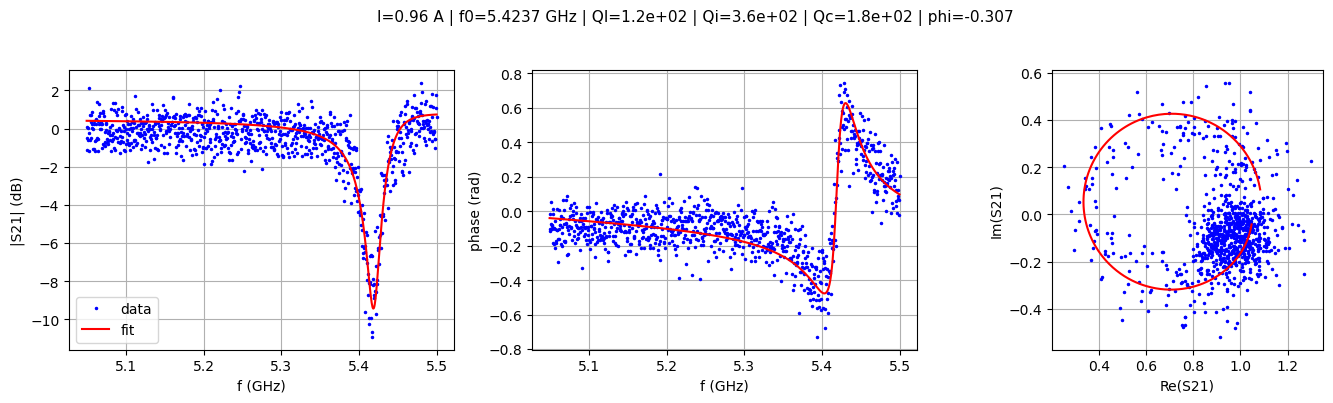

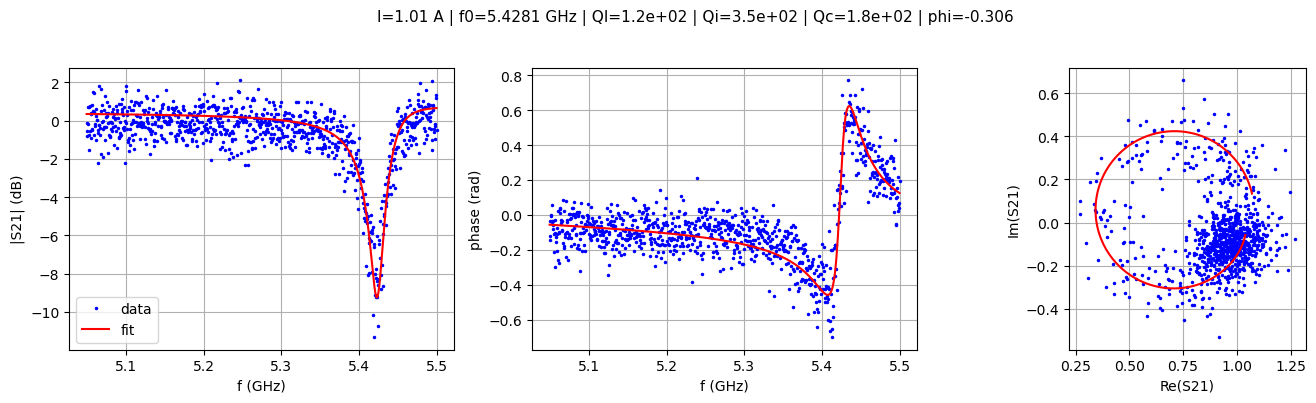

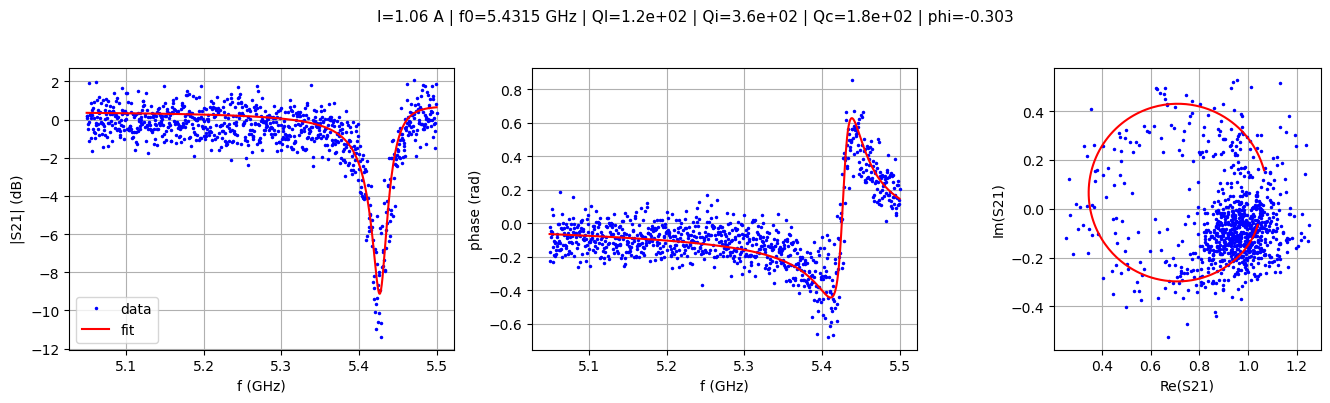

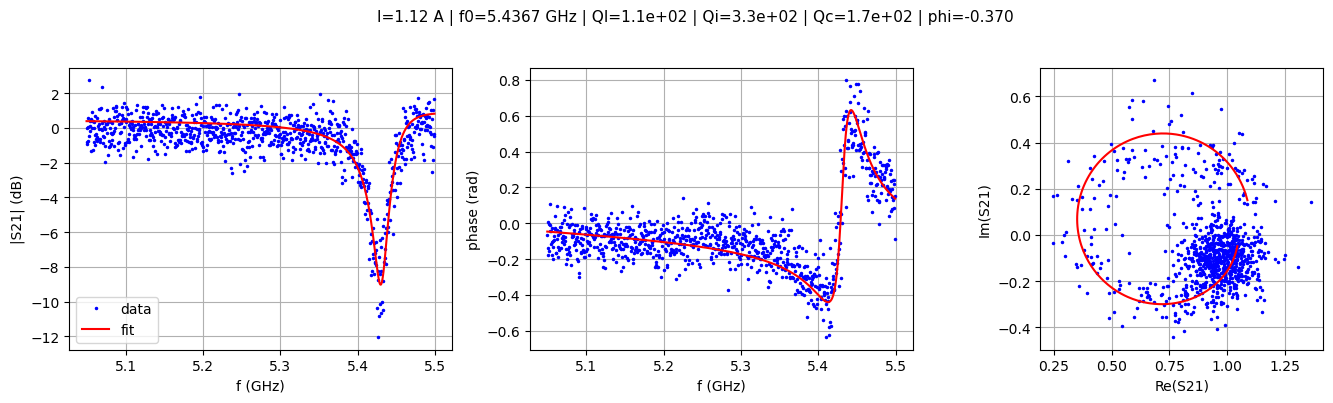

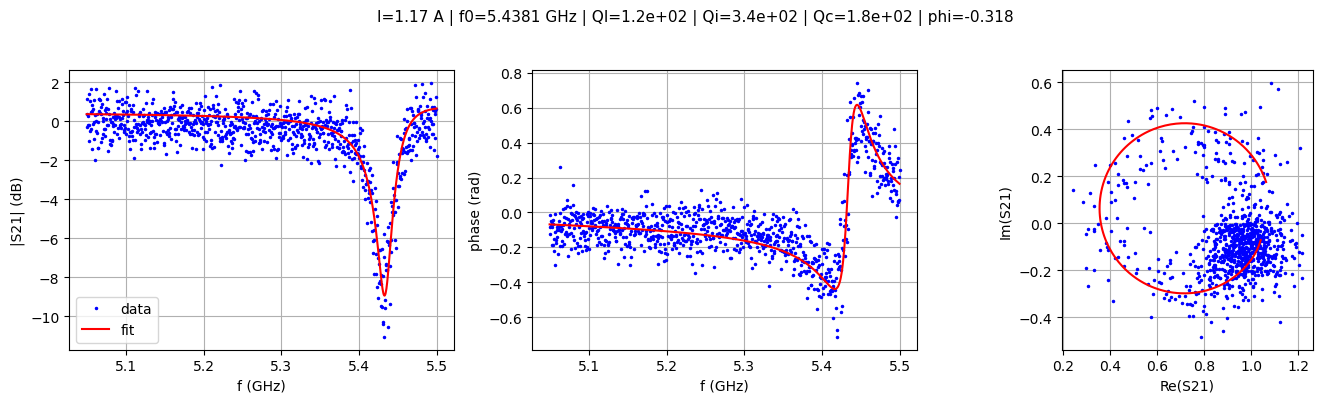

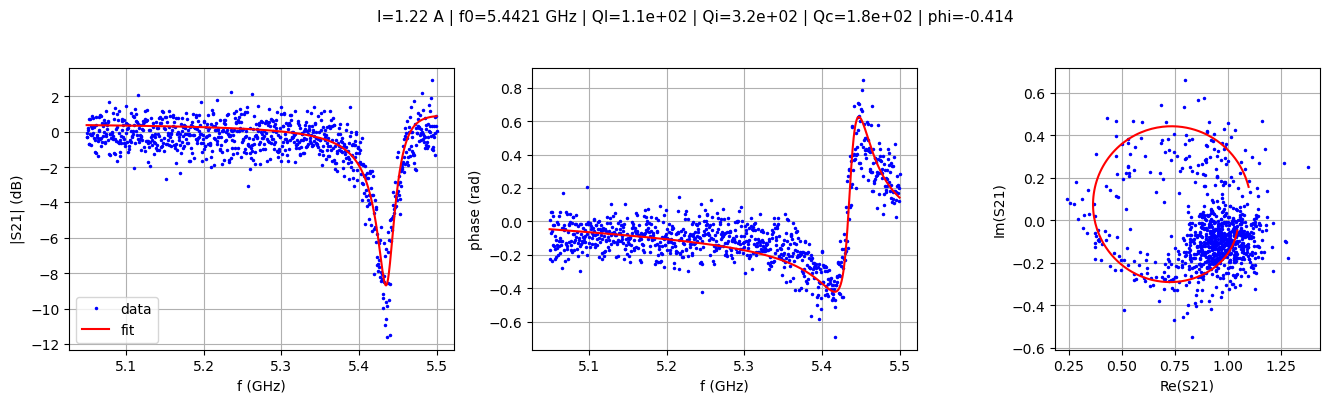

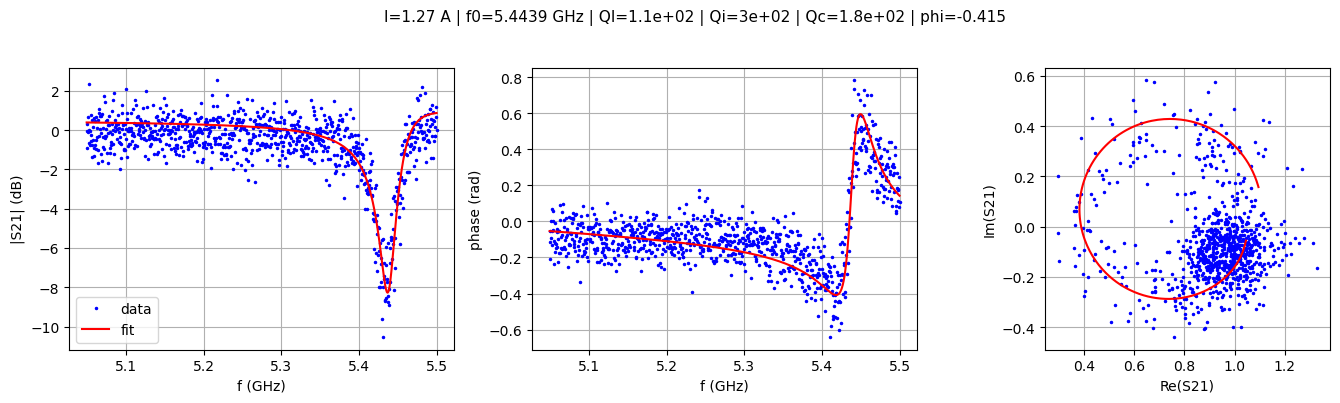

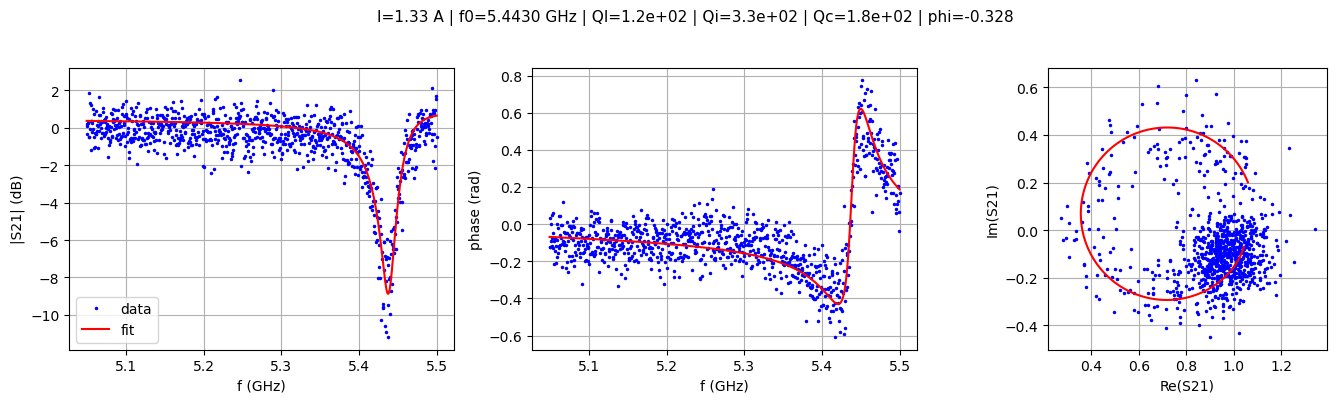

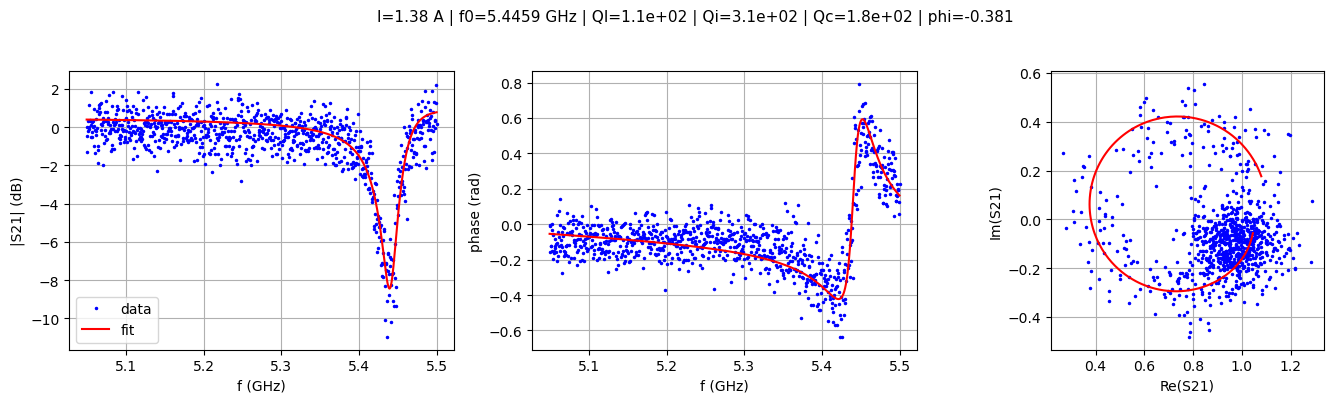

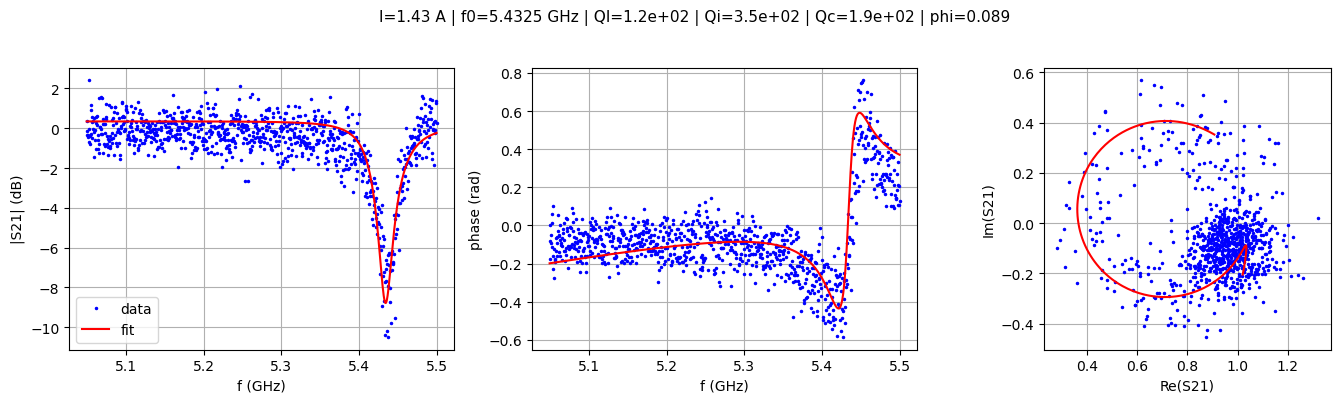

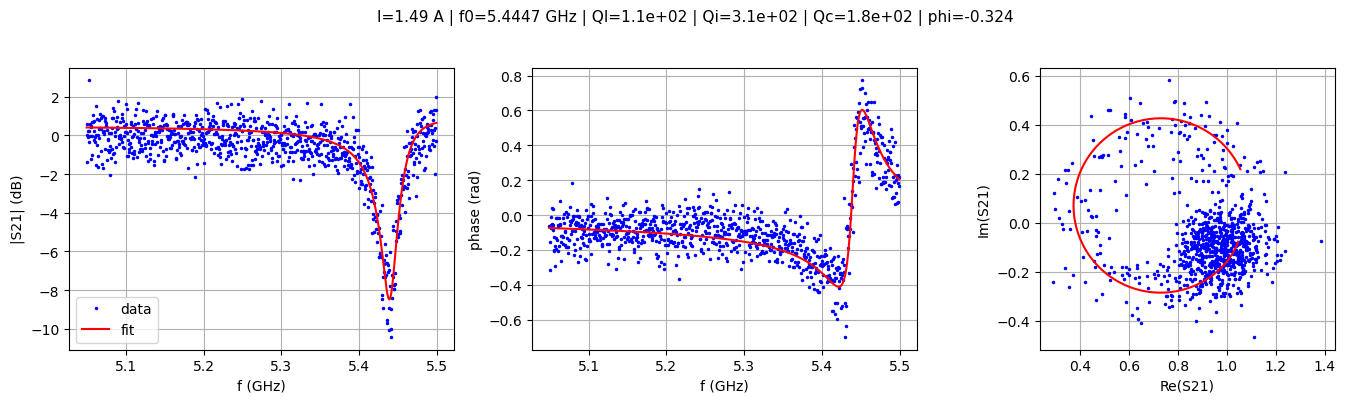

In [52]:
plot_n_examples_by_regions(n_per_region=19, electric_delay_guess=ELECTRIC_DELAY_GUESS)

Depth mismatch array shape: (216, 4)


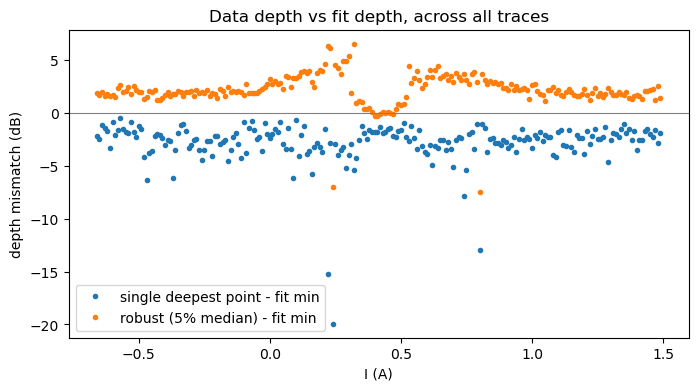

In [17]:
depth_mismatch = []
for Ival, idx in groups.items():
    f_trace, z_trace = Freq[idx], Z[idx]
    good = np.isfinite(f_trace) & np.isfinite(z_trace.real) & np.isfinite(z_trace.imag)
    if np.count_nonzero(good) < MIN_POINTS_PER_TRACE:
        continue
    try:
        fitres, (f_sorted, z_sorted, port) = fit_notch_trace(f_trace[good], z_trace[good], electric_delay_guess=ELECTRIC_DELAY_GUESS)
        data_dB = 20*np.log10(np.abs(z_sorted))
        data_min = np.min(data_dB)
        data_min_robust = np.median(np.sort(data_dB)[:max(1,len(data_dB)//20)])

        f_fit = getattr(port, 'f_data', f_sorted)
        z_fit = getattr(port, 'z_data_sim', None)
        if z_fit is None:
            z_fit = getattr(port, 'z_data_fit', None)
        fit_min = np.min(20*np.log10(np.abs(z_fit))) if z_fit is not None else np.nan

        depth_mismatch.append((Ival, data_min, data_min_robust, fit_min))
    except Exception as e:
        warnings.warn(f"Failed for I={Ival:.6g}: {e}")   # print the reason instead of swallowing it
        continue

depth_mismatch = np.array(depth_mismatch)
print("Depth mismatch array shape:", depth_mismatch.shape)
plt.figure(figsize=(8,4))
plt.plot(depth_mismatch[:,0], depth_mismatch[:,1] - depth_mismatch[:,3], '.', label='single deepest point - fit min')
plt.plot(depth_mismatch[:,0], depth_mismatch[:,2] - depth_mismatch[:,3], '.', label='robust (5% median) - fit min')
plt.axhline(0, color='gray', lw=0.8)
plt.xlabel('I (A)'); plt.ylabel('depth mismatch (dB)')
plt.legend(); plt.title('Data depth vs fit depth, across all traces')
plt.show()

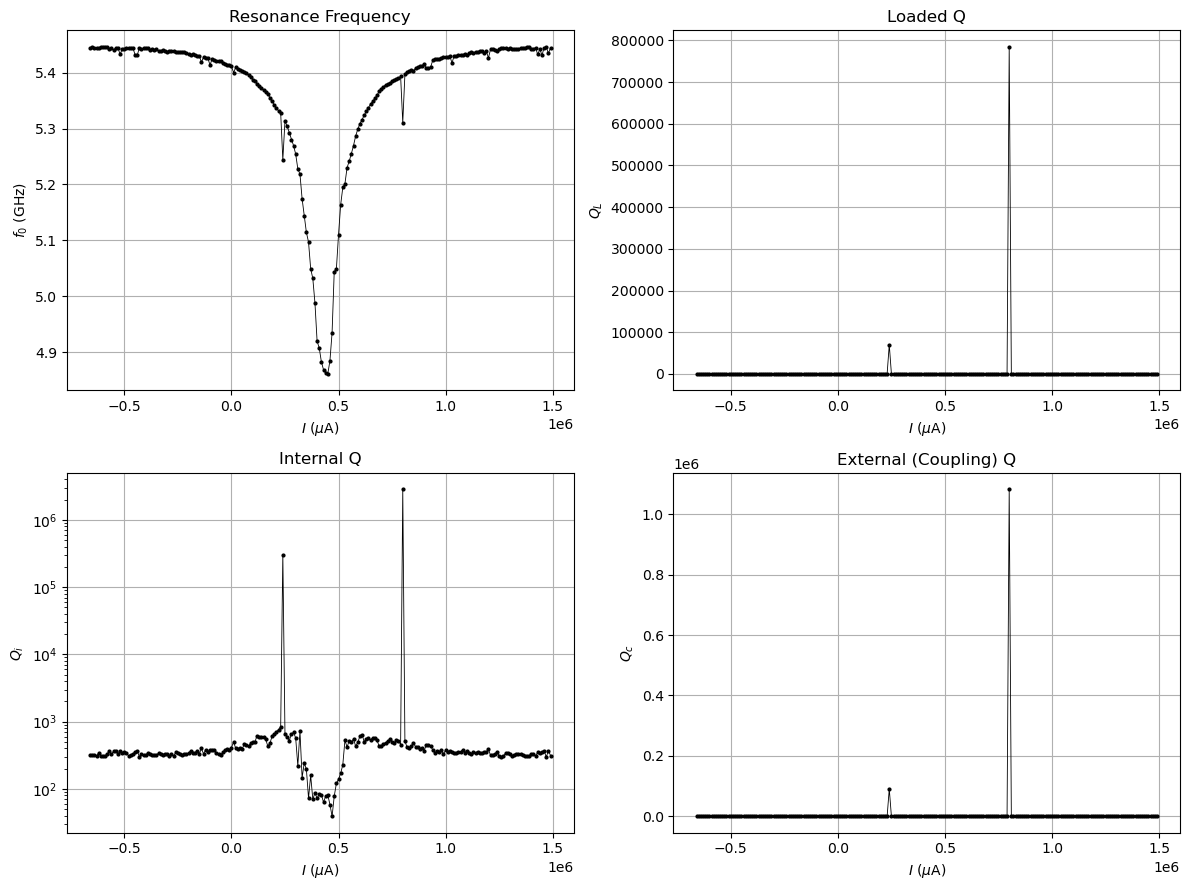

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0,0].plot(df['I']*1e6, df['f0']/1e9, 'k.-', ms=4, lw=0.6)
axes[0,0].set_xlabel(r'$I$ ($\mu$A)')
axes[0,0].set_ylabel(r'$f_0$ (GHz)')
axes[0,0].set_title('Resonance Frequency')
axes[0,0].grid(True)

axes[0,1].plot(df['I']*1e6, df['Ql'], 'k.-', ms=4, lw=0.6)
axes[0,1].set_xlabel(r'$I$ ($\mu$A)')
axes[0,1].set_ylabel(r'$Q_L$')
axes[0,1].set_title('Loaded Q')
axes[0,1].grid(True)

axes[1,0].plot(df['I']*1e6, df['Qi'], 'k.-', ms=4, lw=0.6)
axes[1,0].set_xlabel(r'$I$ ($\mu$A)')
axes[1,0].set_ylabel(r'$Q_i$')
axes[1,0].set_yscale('log')
axes[1,0].set_title('Internal Q')
axes[1,0].grid(True)

axes[1,1].plot(df['I']*1e6, df['Qc'], 'k.-', ms=4, lw=0.6)
axes[1,1].set_xlabel(r'$I$ ($\mu$A)')
axes[1,1].set_ylabel(r'$Q_c$')
axes[1,1].set_title('External (Coupling) Q')
axes[1,1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
np.argmax(df['Ql'])
X = df['Ql']
X[146] = X[145]
X[90] = X[89]


np.float64(168.4726245235258)

In [37]:
np.argmax(df['Qi'])
Y = df['Qi']
Y[146] = Y[145]
Y[90] = Y[89]
Z = df['Qc']
Z[146] = Z[145]
Z[90] = Z[89]
A = df['I']
A[146], A[90]

(np.float64(0.7999999999999999), np.float64(0.24))

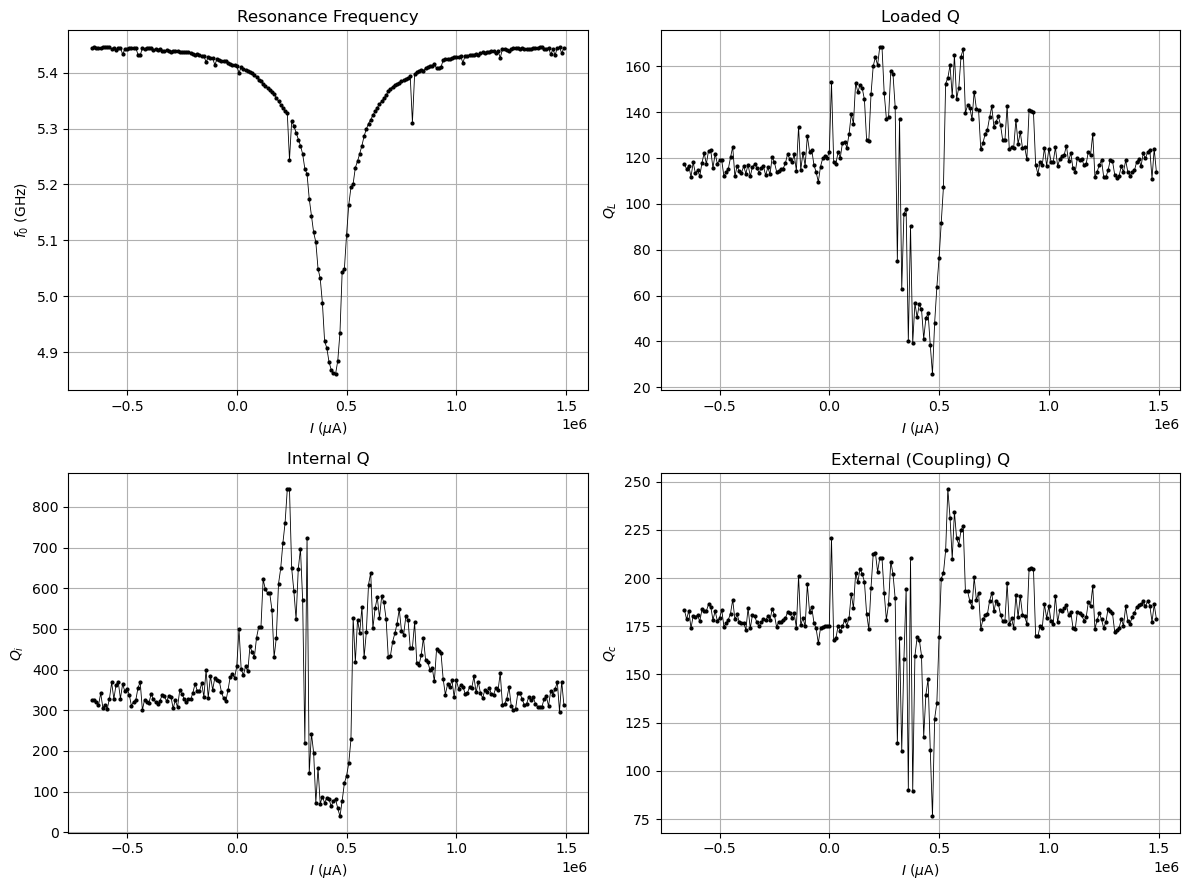

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0,0].plot(df['I']*1e6, df['f0']/1e9, 'k.-', ms=4, lw=0.6)
axes[0,0].set_xlabel(r'$I$ ($\mu$A)')
axes[0,0].set_ylabel(r'$f_0$ (GHz)')
axes[0,0].set_title('Resonance Frequency')
axes[0,0].grid(True)

axes[0,1].plot(df['I']*1e6, X, 'k.-', ms=4, lw=0.6)
axes[0,1].set_xlabel(r'$I$ ($\mu$A)')
axes[0,1].set_ylabel(r'$Q_L$')
axes[0,1].set_title('Loaded Q')
axes[0,1].grid(True)

axes[1,0].plot(df['I']*1e6, Y, 'k.-', ms=4, lw=0.6)
axes[1,0].set_xlabel(r'$I$ ($\mu$A)')
axes[1,0].set_ylabel(r'$Q_i$')
#axes[1,0].set_yscale('log')
axes[1,0].set_title('Internal Q')
axes[1,0].grid(True)

axes[1,1].plot(df['I']*1e6, Z, 'k.-', ms=4, lw=0.6)
axes[1,1].set_xlabel(r'$I$ ($\mu$A)')
axes[1,1].set_ylabel(r'$Q_c$')
axes[1,1].set_title('External (Coupling) Q')
axes[1,1].grid(True)

plt.tight_layout()
plt.show()

In [53]:
df.to_csv('TC-Main-001-resonator-tools-fit-results.csv', index=False)
print("Saved:", df.shape[0], "rows to TC-Main-001-resonator-tools-fit-results.csv")

Saved: 216 rows to TC-Main-001-resonator-tools-fit-results.csv
